# EDA: IBM AML — Small 데이터셋 비교 (HI-Small vs LI-Small)

`eda_v2.ipynb`의 분석 틀을 그대로 가져오되, **Small 크기 두 개(HI-Small, LI-Small)만** 로드해서
나란히 비교합니다. Medium/Large 규모 비교, 6개 파일 전체 스트리밍 EDA는 다루지 않습니다.

- **HI-Small**: High Illicit ratio (자금세탁 비율이 상대적으로 높은 시뮬레이션), 약 508만 건
- **LI-Small**: Low Illicit ratio (자금세탁 비율이 상대적으로 낮은 시뮬레이션), 약 692만 건

두 데이터셋은 서로 독립적으로 생성된 별도 시뮬레이션입니다. 계좌 ID가 우연히 같은 문자열이어도
실제로는 다른 계좌이므로, 계좌 단위 통계(팬인/팬아웃 등)는 절대 두 데이터셋을 섞지 않고
데이터셋별로 따로 계산한 뒤 비교합니다.

1. 환경 / 스타일 설정 및 데이터 경로
2. 원본 파일 미리보기
3. 데이터 로드 (Trans / Accounts / Patterns)
4. 기본 정보 비교 (shape, dtype, 결측치, 중복)
5. 타겟 변수(Is Laundering) 분포 비교
6. 시간 패턴 비교
7. 거래 금액 분포 비교
8. 통화 / 결제 수단(Payment Format) 비교
9. 자금 흐름 유형 비교 (셀프이체 / 동일은행 / 타행)
10. 계좌 그래프 구조 비교 (팬인/팬아웃)
11. Accounts 메타데이터 비교 (은행 국가 / 엔티티 유형)
12. 라운더링 패턴 유형 비교
13. 요약


## 1. 환경 / 스타일 설정 및 데이터 경로

In [44]:
pattern = re.compile(r"^(HI|LI)-(Small|Medium|Large)_(Trans|accounts|Patterns)$")

def find_datasets_dir():
    candidates = [Path.cwd() / "datasets", Path.cwd().parent / "datasets", Path.cwd()]
    for cand in candidates:
        if cand.exists() and any(pattern.match(f.stem) for f in cand.rglob("*") if f.is_file()):
            return cand
    raise FileNotFoundError(
        "datasets 폴더를 찾을 수 없습니다. HI-Small_Trans.csv 등이 있는 경로를 datasets_dir에 직접 지정하세요."
    )

datasets_dir = find_datasets_dir()
print("데이터 경로:", datasets_dir)

rows = []
for f in datasets_dir.rglob("*"):
    if not f.is_file():
        continue
    m = pattern.match(f.stem)
    if m:
        ratio, size, ftype = m.groups()
        rows.append({"ratio": ratio, "size": size, "type": ftype, "path": f})

catalog = pd.DataFrame(rows).sort_values(["ratio", "size", "type"]).reset_index(drop=True)

# Small 크기(HI-Small, LI-Small)만 사용
catalog = catalog.query("size == 'Small'").reset_index(drop=True)
catalog

데이터 경로: /workspace/money_laundry/datasets


,ratio,size,type,path
0,HI,Small,Patterns,/workspace/money_laundry/datasets/HI-Small_Pat...
1,HI,Small,Trans,/workspace/money_laundry/datasets/HI-Small_Tra...
2,HI,Small,accounts,/workspace/money_laundry/datasets/HI-Small_acc...
3,LI,Small,Patterns,/workspace/money_laundry/datasets/LI-Small_Pat...
4,LI,Small,Trans,/workspace/money_laundry/datasets/LI-Small_Tra...
5,LI,Small,accounts,/workspace/money_laundry/datasets/LI-Small_acc...


## 2. 원본 파일 미리보기 (HI-Small / LI-Small)

In [3]:
for ratio in ["HI", "LI"]:
    label = f"{ratio}-Small"
    print("=" * 70)
    print(label)
    print("=" * 70)
    for ftype in ["Trans", "accounts"]:
        path = catalog.query("ratio==@ratio and type==@ftype")["path"].iloc[0]
        head_df = pd.read_csv(path, nrows=5)
        print(f"--- {ftype} ({path.name}) ---")
        print("컬럼:", head_df.columns.tolist())
        display(head_df)
    patterns_path = catalog.query("ratio==@ratio and type=='Patterns'")["path"].iloc[0]
    with open(patterns_path) as f:
        preview = [next(f) for _ in range(10)]
    print(f"--- Patterns ({patterns_path.name}) 미리보기 ---")
    print("".join(preview))
    print()

HI-Small
--- Trans (HI-Small_Trans.csv) ---
컬럼: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


--- accounts (HI-Small_accounts.csv) ---
컬럼: ['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name']


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889


--- Patterns (HI-Small_Patterns.txt) 미리보기 ---
BEGIN LAUNDERING ATTEMPT - FAN-OUT:  Max 16-degree Fan-Out
2022/09/01 00:06,021174,800737690,012,80011F990,2848.96,Euro,2848.96,Euro,ACH,1
2022/09/01 04:33,021174,800737690,020,80020C5B0,8630.40,Euro,8630.40,Euro,ACH,1
2022/09/01 09:14,021174,800737690,020,80006A5E0,35642.49,Yuan,35642.49,Yuan,ACH,1
2022/09/01 09:56,021174,800737690,00220,8007A5B70,5738987.96,US Dollar,5738987.96,US Dollar,ACH,1
2022/09/01 11:28,021174,800737690,001244,80093C0D0,7254.53,US Dollar,7254.53,US Dollar,ACH,1
2022/09/01 13:13,021174,800737690,00513,80078E200,6990.87,US Dollar,6990.87,US Dollar,ACH,1
2022/09/01 14:11,021174,800737690,020,80066B990,12536.92,Euro,12536.92,Euro,ACH,1
2022/09/02 15:40,021174,800737690,00410,8002CC310,3511.82,Euro,3511.82,Euro,ACH,1
2022/09/02 21:23,021174,800737690,01292,8004030A0,16135.09,US Dollar,16135.09,US Dollar,ACH,1


LI-Small
--- Trans (LI-Small_Trans.csv) ---
컬럼: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,592571.00,US Dollar,592571.00,US Dollar,Cheque,0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,12.32,US Dollar,12.32,US Dollar,Reinvestment,0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0


--- accounts (LI-Small_accounts.csv) ---
컬럼: ['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name']


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,China Bank #2820,314693,81B86A280,800D8CCF0,Corporation #41344
1,France Bank #4585,311253,8187FEA80,800B505E0,Corporation #54497
2,China Bank #2242,39996,803961E00,800D03F60,Partnership #36904
3,National Bank of Newport,331440,81B075800,801567C10,Corporation #16224
4,UK Bank #33,135417,80CF87C80,801085E00,Partnership #72930


--- Patterns (LI-Small_Patterns.txt) 미리보기 ---
BEGIN LAUNDERING ATTEMPT - FAN-IN:  Max 3-degree Fan-In
2022/09/01 02:38,001812,80279F810,0110,8000A94C0,10154.74,Australian Dollar,10154.74,Australian Dollar,ACH,1
2022/09/02 14:36,022595,80279F8B0,0110,8000A94C0,5326.79,Australian Dollar,5326.79,Australian Dollar,ACH,1
2022/09/03 14:09,001120,800E36A50,0110,8000A94C0,4634.81,Australian Dollar,4634.81,Australian Dollar,ACH,1
END LAUNDERING ATTEMPT - FAN-IN

BEGIN LAUNDERING ATTEMPT - FAN-IN:  Max 8-degree Fan-In
2022/09/01 03:17,003671,801BF8E70,002557,8016B3750,8099.96,Euro,8099.96,Euro,ACH,1
2022/09/01 06:27,015,80074C7E0,002557,8016B3750,10468.56,Euro,10468.56,Euro,ACH,1
2022/09/01 10:04,002557,80107C9A0,002557,8016B3750,10270.07,Euro,10270.07,Euro,ACH,1




## 3. 데이터 로드 (Trans / Accounts / Patterns)

In [4]:
trans_columns = ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
                  'Amount Received', 'Receiving Currency', 'Amount Paid',
                  'Payment Currency', 'Payment Format', 'Is Laundering']

def parse_patterns(path):
    records = []
    attempt_id = 0
    pattern_type = pattern_desc = None
    with open(path) as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith("BEGIN LAUNDERING ATTEMPT"):
                attempt_id += 1
                header = line.replace("BEGIN LAUNDERING ATTEMPT - ", "")
                if ":" in header:
                    pattern_type, pattern_desc = [x.strip() for x in header.split(":", 1)]
                else:
                    pattern_type, pattern_desc = header.strip(), ""
            elif line.startswith("END LAUNDERING ATTEMPT") or line.strip() == "":
                continue
            else:
                fields = line.split(",")
                if len(fields) == len(trans_columns):
                    row = dict(zip(trans_columns, fields))
                    row["attempt_id"] = attempt_id
                    row["pattern_type"] = pattern_type
                    row["pattern_desc"] = pattern_desc
                    records.append(row)
    return pd.DataFrame(records)


def load_trans(path):
    df = pd.read_csv(path)
    df = df.rename(columns={"Account": "From Account", "Account.1": "To Account"})
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df["date"] = df["Timestamp"].dt.date
    df["hour"] = df["Timestamp"].dt.hour

    same_account = (df["From Bank"] == df["To Bank"]) & (df["From Account"] == df["To Account"])
    same_bank_diff_account = (df["From Bank"] == df["To Bank"]) & (df["From Account"] != df["To Account"])
    cross_bank = df["From Bank"] != df["To Bank"]
    df["flow_type"] = np.select(
        [same_account, same_bank_diff_account, cross_bank],
        ["동일 계좌(셀프)", "동일 은행/타 계좌", "타 은행 간"],
        default="unknown",
    )
    return df


dfs, accounts_dfs, patterns_dfs = {}, {}, {}

for ratio in ["HI", "LI"]:
    label = f"{ratio}-Small"
    trans_path = catalog.query("ratio==@ratio and type=='Trans'")["path"].iloc[0]
    accounts_path = catalog.query("ratio==@ratio and type=='accounts'")["path"].iloc[0]
    patterns_path = catalog.query("ratio==@ratio and type=='Patterns'")["path"].iloc[0]

    dfs[label] = load_trans(trans_path)
    accounts_dfs[label] = pd.read_csv(accounts_path)
    patterns_dfs[label] = parse_patterns(patterns_path)
    patterns_dfs[label]["Amount Paid"] = patterns_dfs[label]["Amount Paid"].astype(float)

    print(f"{label}: trans={dfs[label].shape}, accounts={accounts_dfs[label].shape}, "
          f"patterns_rows={len(patterns_dfs[label]):,}")

HI-Small: trans=(5078345, 14), accounts=(518581, 5), patterns_rows=3,209
LI-Small: trans=(6924049, 14), accounts=(712688, 5), patterns_rows=1,023


## 4. 기본 정보 비교 (shape / dtype / 결측치 / 중복)

In [23]:
info_rows = []
dup_rows = []
for label in WORLDS:
    df = dfs[label]
    info_rows.append({
        "dataset": label,
        "rows": len(df),
        "columns": df.shape[1],
        "결측치_총합": int(df.isna().sum().sum()),
        "완전_중복행": int(df.duplicated().sum()),
        "고유_From_Account": df["From Account"].nunique(),
        "고유_To_Account": df["To Account"].nunique(),
        "고유_From_Bank": df["From Bank"].nunique(),
        "고유_To_Bank": df["To Bank"].nunique(),
    })
    # 완전 중복행 실제 내용 확인 (keep=False로 중복된 행들을 한 그룹으로 묶어서 표시)
    dup_mask = df.duplicated(keep=False)
    n_extra = df.duplicated(keep="first").sum()  # 보통 말하는 "중복행 개수"(그룹당 첫 행 제외)
    dup_row = df.loc[dup_mask].sort_values(list(df.columns[:11]))

    print(f"중복에 연루된 행 {dup_mask.sum():,}건 (추가로 잡히는 중복행 {n_extra:,}건)")
    dup_rows.append(dup_row)

info_summary = pd.DataFrame(info_rows).set_index("dataset")
info_summary

중복에 연루된 행 18건 (추가로 잡히는 중복행 9건)
중복에 연루된 행 16건 (추가로 잡히는 중복행 8건)


,rows,columns,결측치_총합,완전_중복행,고유_From_Account,고유_To_Account,고유_From_Bank,고유_To_Bank
dataset,,,,,,,,
HI-Small,5078345,14,0,9,496995,420636,30470,15811
LI-Small,6924049,14,0,8,681281,576176,41814,21588


In [24]:
for label, d in zip(WORLDS, dup_rows):
    print(label)
    display(d.head(20))

HI-Small


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,date,hour,flow_type
863294,2022-09-01 16:20:00,12004,800C927C1,220,813D8C1E1,0.000008,Bitcoin,0.000008,Bitcoin,Bitcoin,0,2022-09-01,16,타 은행 간
863296,2022-09-01 16:20:00,12004,800C927C1,220,813D8C1E1,0.000008,Bitcoin,0.000008,Bitcoin,Bitcoin,0,2022-09-01,16,타 은행 간
863293,2022-09-01 16:20:00,12004,800C927C1,12004,800C927C0,0.000008,Bitcoin,0.080000,Euro,ACH,0,2022-09-01,16,동일 은행/타 계좌
863295,2022-09-01 16:20:00,12004,800C927C1,12004,800C927C0,0.000008,Bitcoin,0.080000,Euro,ACH,0,2022-09-01,16,동일 은행/타 계좌
3684003,2022-09-07 21:25:00,29992,8099A29B1,220,813725AE1,0.000003,Bitcoin,0.000003,Bitcoin,Bitcoin,0,2022-09-07,21,타 은행 간
3684005,2022-09-07 21:25:00,29992,8099A29B1,220,813725AE1,0.000003,Bitcoin,0.000003,Bitcoin,Bitcoin,0,2022-09-07,21,타 은행 간
4166785,2022-09-08 21:05:00,113779,811144AB1,53744,813C777F1,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,0,2022-09-08,21,타 은행 간
4166787,2022-09-08 21:05:00,113779,811144AB1,53744,813C777F1,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,0,2022-09-08,21,타 은행 간
4166784,2022-09-08 21:05:00,113779,811144AB1,113779,811144AB0,0.000002,Bitcoin,0.020000,US Dollar,ACH,0,2022-09-08,21,동일 은행/타 계좌
4166786,2022-09-08 21:05:00,113779,811144AB1,113779,811144AB0,0.000002,Bitcoin,0.020000,US Dollar,ACH,0,2022-09-08,21,동일 은행/타 계좌


LI-Small


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,date,hour,flow_type
676694,2022-09-01 05:03:00,21260,8085A09D1,72146,81AB967E1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,2022-09-01,5,타 은행 간
676696,2022-09-01 05:03:00,21260,8085A09D1,72146,81AB967E1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,2022-09-01,5,타 은행 간
790828,2022-09-01 07:44:00,231616,814E45511,171546,81B324AC1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,2022-09-01,7,타 은행 간
790830,2022-09-01 07:44:00,231616,814E45511,171546,81B324AC1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,2022-09-01,7,타 은행 간
2027614,2022-09-02 11:09:00,28335,804B468F1,171669,81BBCDAB1,0.000007,Bitcoin,0.000007,Bitcoin,Bitcoin,0,2022-09-02,11,타 은행 간
2027616,2022-09-02 11:09:00,28335,804B468F1,171669,81BBCDAB1,0.000007,Bitcoin,0.000007,Bitcoin,Bitcoin,0,2022-09-02,11,타 은행 간
3482551,2022-09-05 12:44:00,22661,80D016C81,269294,81A245E81,0.000005,Bitcoin,0.000005,Bitcoin,Bitcoin,0,2022-09-05,12,타 은행 간
3482553,2022-09-05 12:44:00,22661,80D016C81,269294,81A245E81,0.000005,Bitcoin,0.000005,Bitcoin,Bitcoin,0,2022-09-05,12,타 은행 간
4180129,2022-09-06 14:16:00,19970,804E44F11,169489,8197DC971,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,2022-09-06,14,타 은행 간
4180131,2022-09-06 14:16:00,19970,804E44F11,169489,8197DC971,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,2022-09-06,14,타 은행 간


In [6]:
# dtype은 두 데이터셋이 동일한 스키마를 쓰는지만 빠르게 확인
for label in WORLDS:
    print(f"--- {label} dtypes ---")
    print(dfs[label].dtypes)
    print()

--- HI-Small dtypes ---
Timestamp             datetime64[us]
From Bank                      int64
From Account                     str
To Bank                        int64
To Account                       str
Amount Received              float64
Receiving Currency               str
Amount Paid                  float64
Payment Currency                 str
Payment Format                   str
Is Laundering                  int64
date                          object
hour                           int32
flow_type                        str
dtype: object

--- LI-Small dtypes ---
Timestamp             datetime64[us]
From Bank                      int64
From Account                     str
To Bank                        int64
To Account                       str
Amount Received              float64
Receiving Currency               str
Amount Paid                  float64
Payment Currency                 str
Payment Format                   str
Is Laundering                  int64
date        

## 5. 타겟 변수(Is Laundering) 분포 비교

               정상    세탁   세탁비율(%)        정상:세탁
dataset                                       
HI-Small  5073168  5177  0.101943   979.943597
LI-Small  6920484  3565  0.051487  1941.229734


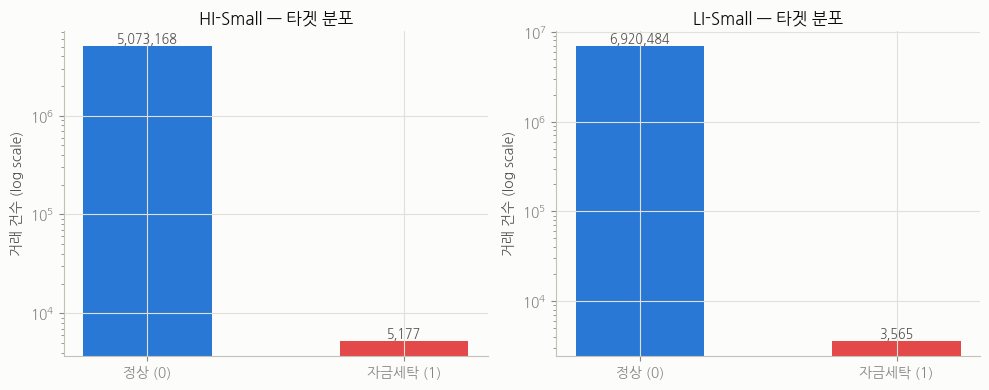

In [7]:
target_summary = []
for label in WORLDS:
    df = dfs[label]
    counts = df["Is Laundering"].value_counts().sort_index()
    rate = df["Is Laundering"].mean() * 100
    ratio_val = counts[0] / counts[1]
    target_summary.append({"dataset": label, "정상": counts.get(0, 0), "세탁": counts.get(1, 0),
                            "세탁비율(%)": rate, "정상:세탁": ratio_val})
target_summary = pd.DataFrame(target_summary).set_index("dataset")
print(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, label in zip(axes, WORLDS):
    counts = dfs[label]["Is Laundering"].value_counts().sort_index()
    bars = ax.bar(["정상 (0)", "자금세탁 (1)"], counts.values,
                   color=[CATEGORICAL[0], CATEGORICAL[7]], width=0.5)
    ax.set_yscale("log")
    ax.set_title(f"{label} — 타겟 분포")
    ax.set_ylabel("거래 건수 (log scale)")
    for b, v in zip(bars, counts.values):
        ax.annotate(f"{v:,}", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                     fontsize=9, color=INK_SECONDARY)
plt.tight_layout()
plt.show()

## 6. 시간 패턴 비교

HI-Small 거래 기간: 2022-09-01 00:00:00 ~ 2022-09-18 16:18:00
LI-Small 거래 기간: 2022-09-01 00:00:00 ~ 2022-09-17 15:28:00


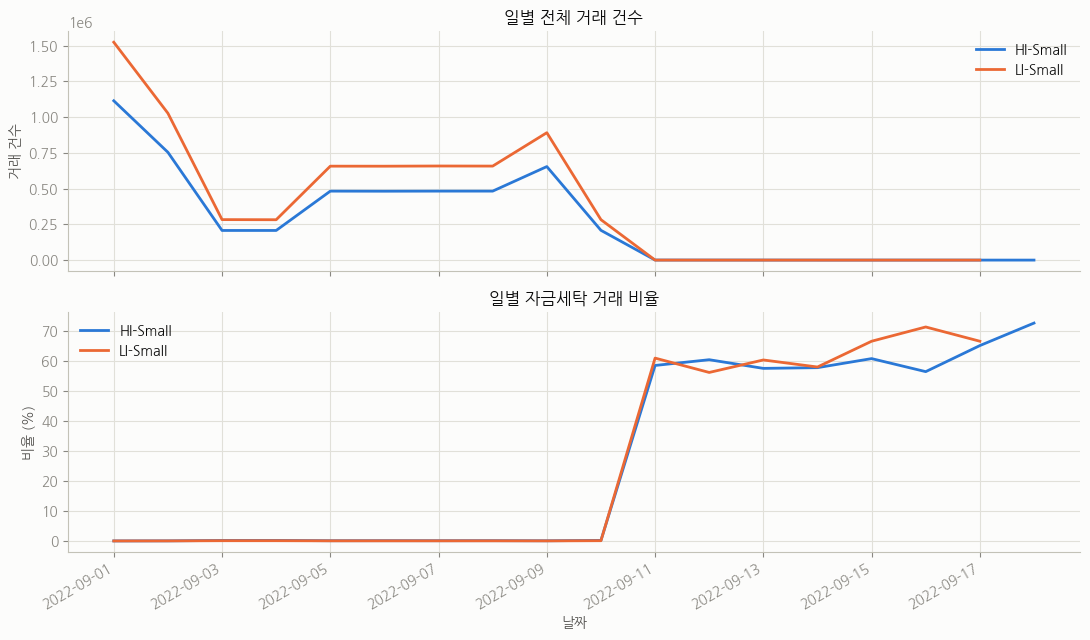

In [8]:
for label in WORLDS:
    df = dfs[label]
    print(f"{label} 거래 기간:", df["Timestamp"].min(), "~", df["Timestamp"].max())

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=False)
for label in WORLDS:
    df = dfs[label]
    daily = df.groupby("date").agg(total=("Is Laundering", "size"), laundering=("Is Laundering", "sum"))
    daily["rate_pct"] = daily["laundering"] / daily["total"] * 100
    axes[0].plot(daily.index, daily["total"], color=WORLD_COLOR[label], linewidth=2, label=label)
    axes[1].plot(daily.index, daily["rate_pct"], color=WORLD_COLOR[label], linewidth=2, label=label)

axes[0].set_title("일별 전체 거래 건수")
axes[0].set_ylabel("거래 건수")
axes[0].legend(frameon=False)

axes[1].set_title("일별 자금세탁 거래 비율")
axes[1].set_ylabel("비율 (%)")
axes[1].set_xlabel("날짜")
axes[1].legend(frameon=False)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [26]:
daily_by_world = {}
for label in WORLDS:
    df = dfs[label]
    daily = df.groupby("date").agg(total=("Is Laundering", "size"), laundering=("Is Laundering", "sum"))
    daily["rate_pct"] = daily["laundering"] / daily["total"] * 100
    daily_by_world[label] = daily
    # print(f"--- {label} 일별 거래 건수 ---")
    # print(daily)
    # print()

# 두 데이터셋을 나란히 비교하고 싶으면
daily_compare = pd.concat(
    {label: daily_by_world[label]["total"] for label in WORLDS}, axis=1
)
daily_compare

,HI-Small,LI-Small
date,,
2022-09-01,1114921,1524807.0
2022-09-02,754449,1027758.0
2022-09-03,207382,283326.0
2022-09-04,207430,282476.0
2022-09-05,482650,657397.0
2022-09-06,482089,657170.0
2022-09-07,482751,658504.0
2022-09-08,482773,657938.0
2022-09-09,654467,891573.0


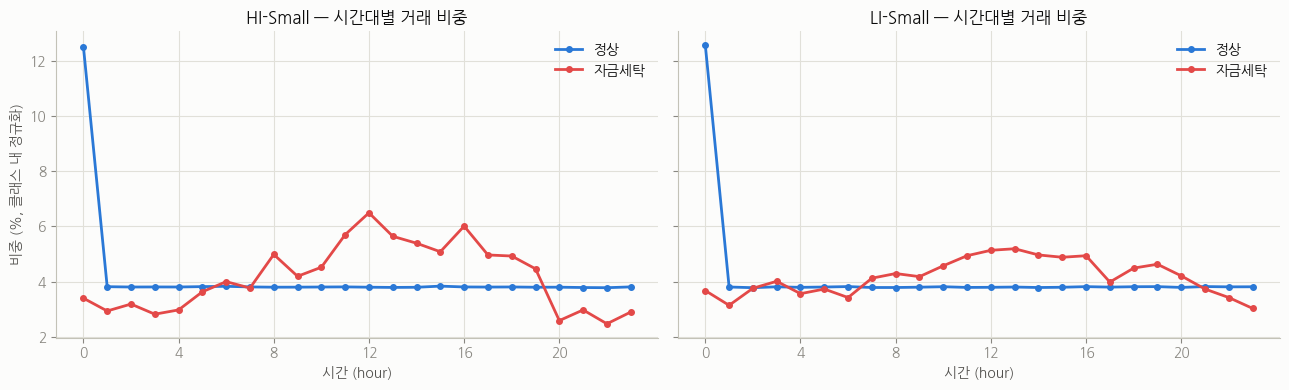

In [9]:
# 시간대별 비중 비교 (클래스 내부에서 정규화 — 표본 수 차이의 영향을 제거하고 '모양'만 비교)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, label in zip(axes, WORLDS):
    df = dfs[label]
    hour_normal = df.loc[df["Is Laundering"] == 0, "hour"].value_counts(normalize=True).sort_index()
    hour_laundering = df.loc[df["Is Laundering"] == 1, "hour"].value_counts(normalize=True).sort_index()
    ax.plot(hour_normal.index, hour_normal.values * 100, color=CATEGORICAL[0], linewidth=2,
            marker="o", markersize=4, label="정상")
    ax.plot(hour_laundering.index, hour_laundering.values * 100, color=CATEGORICAL[7], linewidth=2,
            marker="o", markersize=4, label="자금세탁")
    ax.set_xlabel("시간 (hour)")
    ax.set_title(f"{label} — 시간대별 거래 비중")
    ax.set_xticks(range(0, 24, 4))
    ax.legend(frameon=False)
axes[0].set_ylabel("비중 (%, 클래스 내 정규화)")
plt.tight_layout()
plt.show()

## 7. 거래 금액(Amount) 분포 비교

--- HI-Small Amount Paid describe ---
count    5.078345e+06
mean     4.509273e+06
std      8.697728e+08
min      1.000000e-06
25%      1.844800e+02
50%      1.414540e+03
75%      1.229784e+04
max      1.046302e+12
Name: Amount Paid, dtype: float64

--- LI-Small Amount Paid describe ---
count    6.924049e+06
mean     4.676036e+06
std      1.544099e+09
min      1.000000e-06
25%      1.753800e+02
50%      1.399440e+03
75%      1.222687e+04
max      3.644854e+12
Name: Amount Paid, dtype: float64



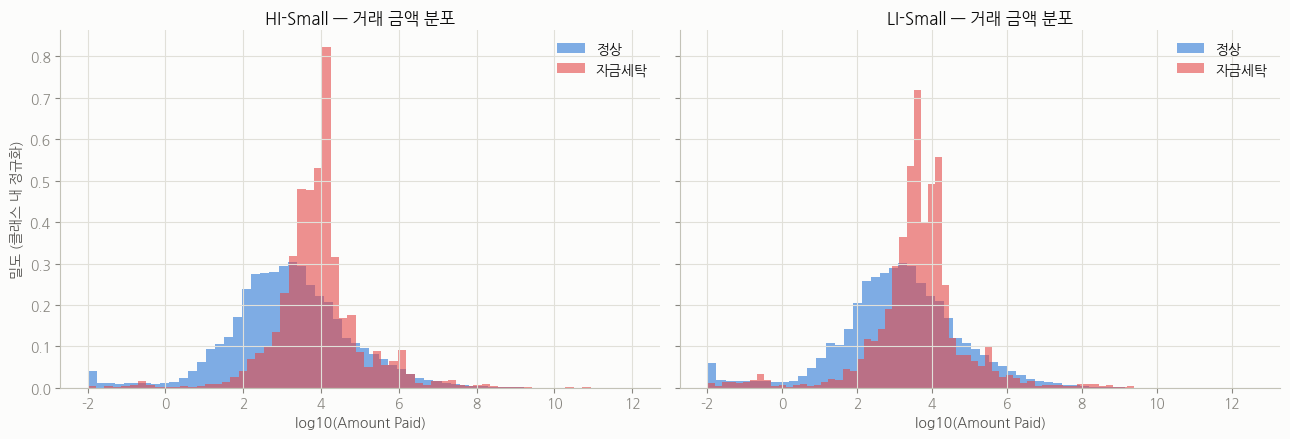

In [10]:
for label in WORLDS:
    print(f"--- {label} Amount Paid describe ---")
    print(dfs[label]["Amount Paid"].describe())
    print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, label in zip(axes, WORLDS):
    df = dfs[label]
    log_amount_normal = np.log10(df.loc[df["Is Laundering"] == 0, "Amount Paid"].clip(lower=0.01))
    log_amount_laundering = np.log10(df.loc[df["Is Laundering"] == 1, "Amount Paid"].clip(lower=0.01))
    ax.hist(log_amount_normal, bins=60, color=CATEGORICAL[0], alpha=0.6, density=True, label="정상")
    ax.hist(log_amount_laundering, bins=60, color=CATEGORICAL[7], alpha=0.6, density=True, label="자금세탁")
    ax.set_xlabel("log10(Amount Paid)")
    ax.set_title(f"{label} — 거래 금액 분포")
    ax.legend(frameon=False)
axes[0].set_ylabel("밀도 (클래스 내 정규화)")
plt.tight_layout()
plt.show()

## 8. 통화 / 결제 수단(Payment Format) 분포 비교

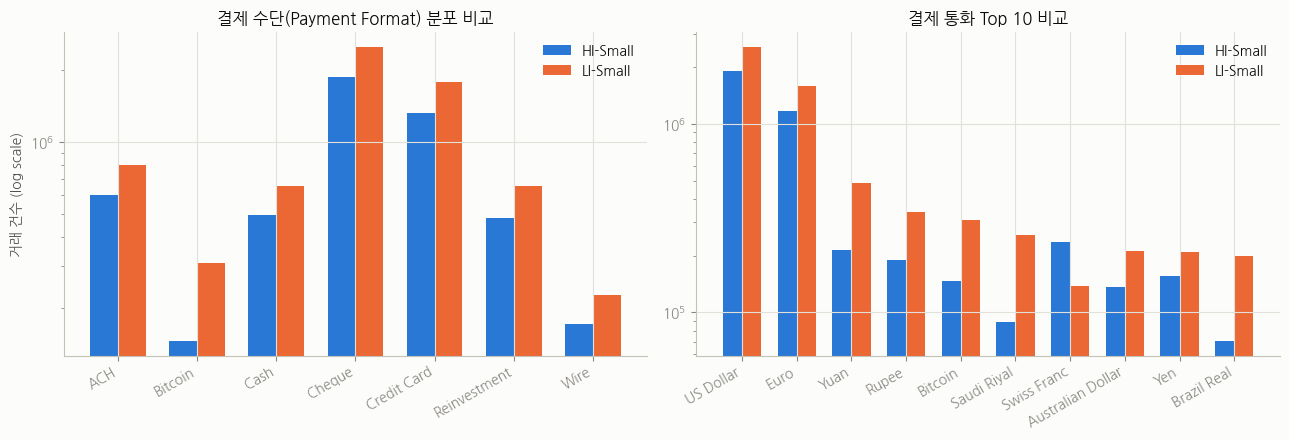

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
width = 0.35
fmt_by_world = {label: dfs[label]["Payment Format"].value_counts() for label in WORLDS}
all_fmts = sorted(set().union(*[s.index for s in fmt_by_world.values()]))
x = np.arange(len(all_fmts))
for i, label in enumerate(WORLDS):
    vals = fmt_by_world[label].reindex(all_fmts, fill_value=0)
    axes[0].bar(x + (i - 0.5) * width, vals.values, width, color=WORLD_COLOR[label], label=label)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_fmts, rotation=30, ha="right")
axes[0].set_yscale("log")
axes[0].set_title("결제 수단(Payment Format) 분포 비교")
axes[0].set_ylabel("거래 건수 (log scale)")
axes[0].legend(frameon=False)

cur_by_world = {label: dfs[label]["Payment Currency"].value_counts() for label in WORLDS}
all_cur = sorted(set().union(*[s.index for s in cur_by_world.values()]),
                  key=lambda c: -max(cur_by_world[l].get(c, 0) for l in WORLDS))[:10]
xc = np.arange(len(all_cur))
for i, label in enumerate(WORLDS):
    vals = [cur_by_world[label].get(c, 0) for c in all_cur]
    axes[1].bar(xc + (i - 0.5) * width, vals, width, color=WORLD_COLOR[label], label=label)
axes[1].set_xticks(xc)
axes[1].set_xticklabels(all_cur, rotation=30, ha="right")
axes[1].set_yscale("log")
axes[1].set_title("결제 통화 Top 10 비교")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

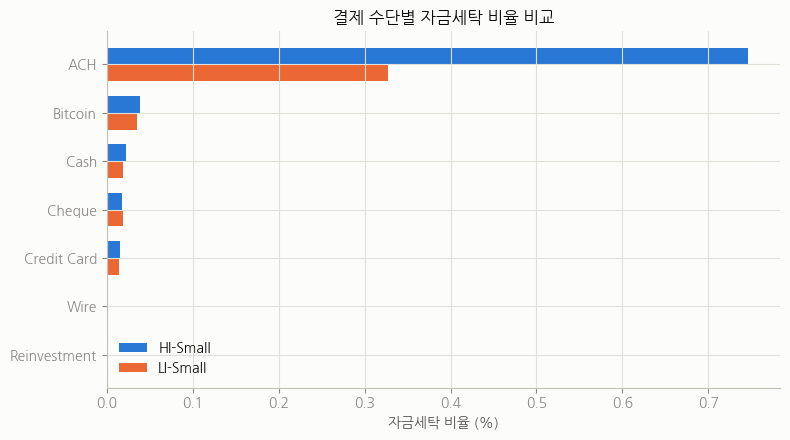

,HI-Small,LI-Small
Payment Format,,
ACH,0.746175,0.327776
Bitcoin,0.038332,0.035575
Cash,0.022001,0.018911
Cheque,0.017379,0.018337
Credit Card,0.015567,0.014660
Reinvestment,0.000000,0.000000
Wire,0.000000,0.000000


In [12]:
# 결제 수단별 자금세탁 비율 비교
fmt_rate_by_world = {label: dfs[label].groupby("Payment Format")["Is Laundering"].mean().mul(100)
                      for label in WORLDS}
all_fmts = sorted(set().union(*[s.index for s in fmt_rate_by_world.values()]),
                   key=lambda f: -max(fmt_rate_by_world[l].get(f, 0) for l in WORLDS))

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(all_fmts))
height = 0.35
for i, label in enumerate(WORLDS):
    vals = [fmt_rate_by_world[label].get(f, 0) for f in all_fmts]
    ax.barh(y + (i - 0.5) * height, vals, height, color=WORLD_COLOR[label], label=label)
ax.set_yticks(y)
ax.set_yticklabels(all_fmts)
ax.invert_yaxis()
ax.set_xlabel("자금세탁 비율 (%)")
ax.set_title("결제 수단별 자금세탁 비율 비교")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

pd.DataFrame(fmt_rate_by_world)

## 9. 자금 흐름 유형 비교 (셀프이체 / 동일은행-타계좌 / 타행 간)

--- HI-Small ---
               거래건수      세탁비율
flow_type                    
동일 계좌(셀프)    591212  0.001861
동일 은행/타 계좌   100120  0.091890
타 은행 간      4387013  0.115660

--- LI-Small ---
               거래건수      세탁비율
flow_type                    
동일 계좌(셀프)    804477  0.000373
동일 은행/타 계좌   107526  0.065101
타 은행 간      6012046  0.058083



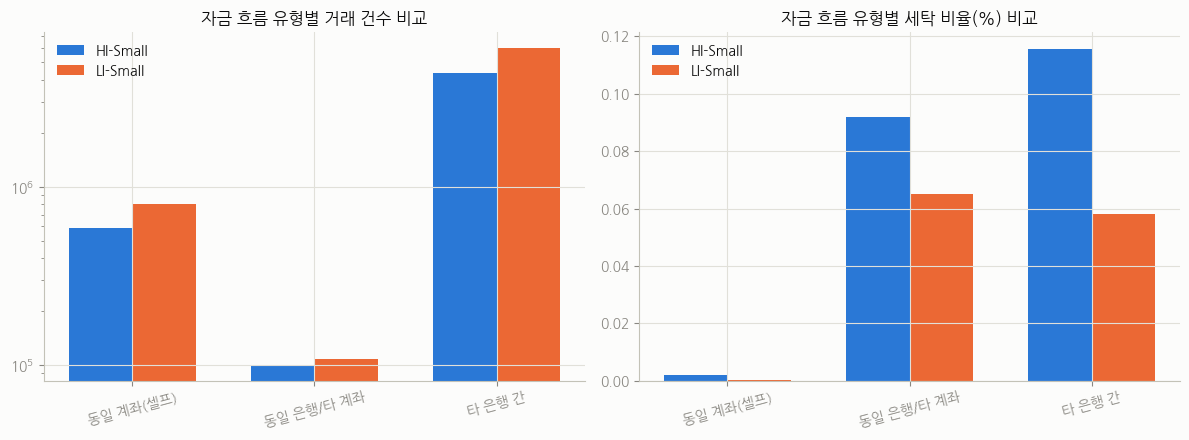

In [13]:
flow_order = ["동일 계좌(셀프)", "동일 은행/타 계좌", "타 은행 간"]
flow_summaries = {}
for label in WORLDS:
    df = dfs[label]
    summary = df.groupby("flow_type")["Is Laundering"].agg(거래건수="size", 세탁비율=lambda s: s.mean() * 100)
    flow_summaries[label] = summary.reindex(flow_order)

for label in WORLDS:
    print(f"--- {label} ---")
    print(flow_summaries[label])
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(flow_order))
width = 0.35
for i, label in enumerate(WORLDS):
    axes[0].bar(x + (i - 0.5) * width, flow_summaries[label]["거래건수"], width,
                color=WORLD_COLOR[label], label=label)
    axes[1].bar(x + (i - 0.5) * width, flow_summaries[label]["세탁비율"], width,
                color=WORLD_COLOR[label], label=label)

axes[0].set_xticks(x)
axes[0].set_xticklabels(flow_order, rotation=15)
axes[0].set_yscale("log")
axes[0].set_title("자금 흐름 유형별 거래 건수 비교")
axes[0].legend(frameon=False)

axes[1].set_xticks(x)
axes[1].set_xticklabels(flow_order, rotation=15)
axes[1].set_title("자금 흐름 유형별 세탁 비율(%) 비교")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## 10. 계좌 그래프 구조 비교 — 팬인(Fan-in) / 팬아웃(Fan-out)

두 데이터셋은 독립적인 시뮬레이션이라 계좌 ID를 절대 섞지 않고, 데이터셋별로 degree를
따로 계산한 뒤 분포만 겹쳐서 비교합니다.

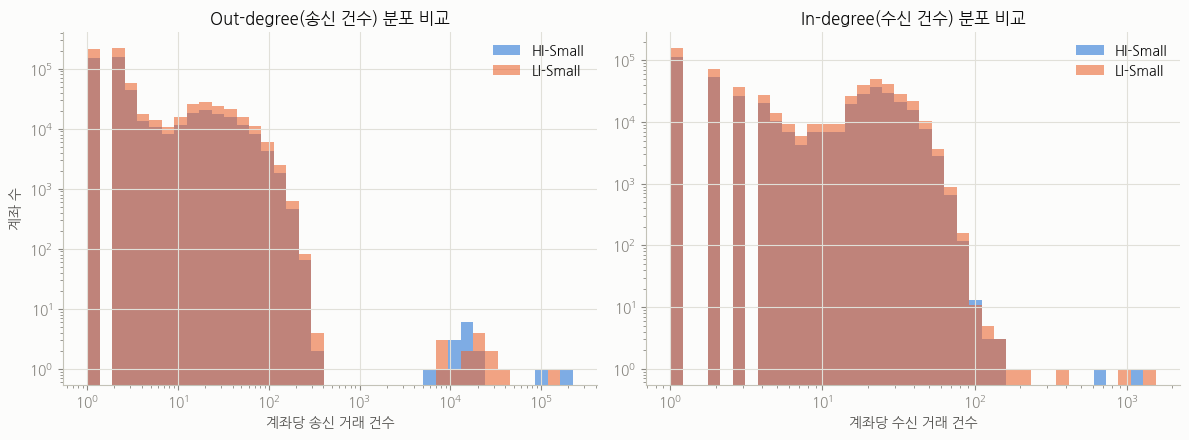

--- HI-Small: 송신(Fan-out) 상위 5개 계좌 ---
From Account
100428660    168672
1004286A8    103018
100428978     20497
1004286F0     18663
100428780     17264
Name: To Account, dtype: int64
--- HI-Small: 수신(Fan-in) 상위 5개 계좌 ---
To Account
100428660    1084
1004286A8     653
80F47A310     159
100428978     150
8018859B0     144
Name: From Account, dtype: int64

--- LI-Small: 송신(Fan-out) 상위 5개 계좌 ---
From Account
10042B660    222037
10042B6A8    138777
10042B6F0     42385
10042B780     30802
10042BA51     28932
Name: To Account, dtype: int64
--- LI-Small: 수신(Fan-in) 상위 5개 계좌 ---
To Account
10042B660    1553
10042B6A8     951
10042B6F0     345
10042B780     223
10042BA08     170
Name: From Account, dtype: int64



In [14]:
degree_by_world = {}
for label in WORLDS:
    df = dfs[label]
    out_degree = df.groupby("From Account")["To Account"].count()
    in_degree = df.groupby("To Account")["From Account"].count()
    degree_by_world[label] = {"out": out_degree, "in": in_degree}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
max_out = max(degree_by_world[l]["out"].max() for l in WORLDS)
max_in = max(degree_by_world[l]["in"].max() for l in WORLDS)
out_bins = np.logspace(0, np.log10(max_out), 40)
in_bins = np.logspace(0, np.log10(max_in), 40)

for label in WORLDS:
    axes[0].hist(degree_by_world[label]["out"], bins=out_bins, color=WORLD_COLOR[label],
                 alpha=0.6, label=label)
    axes[1].hist(degree_by_world[label]["in"], bins=in_bins, color=WORLD_COLOR[label],
                 alpha=0.6, label=label)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Out-degree(송신 건수) 분포 비교")
axes[0].set_xlabel("계좌당 송신 거래 건수")
axes[0].set_ylabel("계좌 수")
axes[0].legend(frameon=False)

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("In-degree(수신 건수) 분포 비교")
axes[1].set_xlabel("계좌당 수신 거래 건수")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

for label in WORLDS:
    print(f"--- {label}: 송신(Fan-out) 상위 5개 계좌 ---")
    print(degree_by_world[label]["out"].sort_values(ascending=False).head(5))
    print(f"--- {label}: 수신(Fan-in) 상위 5개 계좌 ---")
    print(degree_by_world[label]["in"].sort_values(ascending=False).head(5))
    print()

## 11. Accounts 메타데이터 비교 — 은행 국가 / 엔티티 유형

HI-Small: shape=(518581, 5), 고유 은행 수=20,053
LI-Small: shape=(712688, 5), 고유 은행 수=27,652


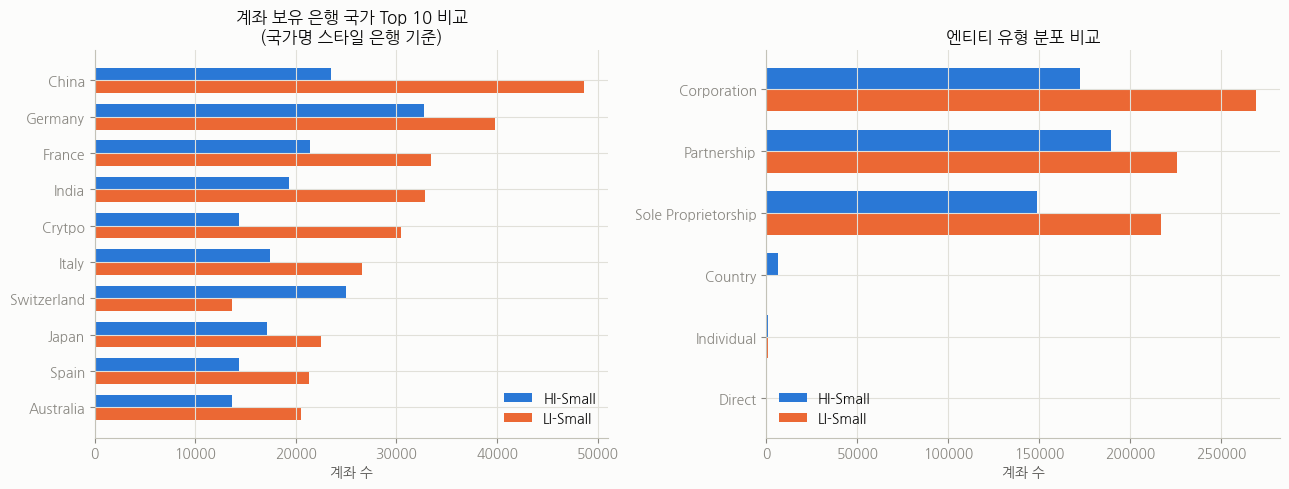

In [15]:
for label in WORLDS:
    adf = accounts_dfs[label]
    print(f"{label}: shape={adf.shape}, 고유 은행 수={adf['Bank Name'].nunique():,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
width = 0.35

country_by_world = {}
for label in WORLDS:
    adf = accounts_dfs[label]
    is_country_style = adf["Bank Name"].str.match(r"^[A-Za-z]+ Bank #\d+$")
    country = adf.loc[is_country_style, "Bank Name"].str.extract(r"^([A-Za-z]+) Bank")[0]
    country_by_world[label] = country.value_counts()

top_countries = sorted(
    set().union(*[s.index for s in country_by_world.values()]),
    key=lambda c: -max(country_by_world[l].get(c, 0) for l in WORLDS),
)[:10]
y = np.arange(len(top_countries))
for i, label in enumerate(WORLDS):
    vals = [country_by_world[label].get(c, 0) for c in top_countries]
    axes[0].barh(y + (i - 0.5) * width, vals, width, color=WORLD_COLOR[label], label=label)
axes[0].set_yticks(y)
axes[0].set_yticklabels(top_countries)
axes[0].invert_yaxis()
axes[0].set_title("계좌 보유 은행 국가 Top 10 비교\n(국가명 스타일 은행 기준)")
axes[0].set_xlabel("계좌 수")
axes[0].legend(frameon=False)

entity_by_world = {}
for label in WORLDS:
    adf = accounts_dfs[label]
    entity_type = adf["Entity Name"].str.extract(r"^(.*?)\s*#\d+$")[0]
    entity_by_world[label] = entity_type.value_counts()

all_entities = sorted(
    set().union(*[s.index for s in entity_by_world.values()]),
    key=lambda e: -max(entity_by_world[l].get(e, 0) for l in WORLDS),
)
ye = np.arange(len(all_entities))
for i, label in enumerate(WORLDS):
    vals = [entity_by_world[label].get(e, 0) for e in all_entities]
    axes[1].barh(ye + (i - 0.5) * width, vals, width, color=WORLD_COLOR[label], label=label)
axes[1].set_yticks(ye)
axes[1].set_yticklabels(all_entities)
axes[1].invert_yaxis()
axes[1].set_title("엔티티 유형 분포 비교")
axes[1].set_xlabel("계좌 수")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## 12. 라운더링 패턴 유형 비교 (Patterns 로그)

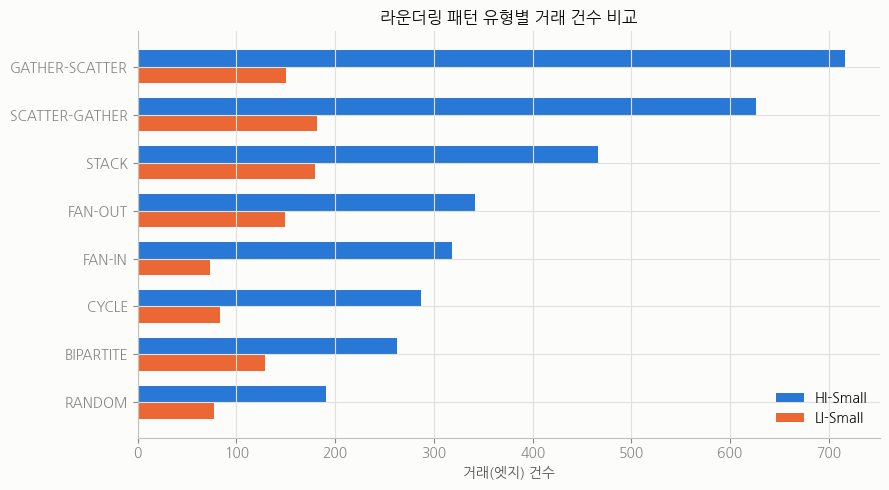

HI-Small: Trans Is Laundering==1 = 5,177건 / Patterns 로그 = 3,209건
LI-Small: Trans Is Laundering==1 = 3,565건 / Patterns 로그 = 1,023건


In [16]:
pattern_counts_by_world = {label: patterns_dfs[label]["pattern_type"].value_counts()
                            for label in WORLDS}
all_patterns = sorted(
    set().union(*[s.index for s in pattern_counts_by_world.values()]),
    key=lambda p: -max(pattern_counts_by_world[l].get(p, 0) for l in WORLDS),
)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(all_patterns))
width = 0.35
for i, label in enumerate(WORLDS):
    vals = [pattern_counts_by_world[label].get(p, 0) for p in all_patterns]
    ax.barh(y + (i - 0.5) * width, vals, width, color=WORLD_COLOR[label], label=label)
ax.set_yticks(y)
ax.set_yticklabels(all_patterns)
ax.invert_yaxis()
ax.set_xlabel("거래(엣지) 건수")
ax.set_title("라운더링 패턴 유형별 거래 건수 비교")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Patterns 로그 거래 건수가 Trans의 Is Laundering==1 건수와 얼마나 일치하는지 확인
for label in WORLDS:
    n_labeled_positive = int(dfs[label]["Is Laundering"].sum())
    n_pattern_rows = len(patterns_dfs[label])
    print(f"{label}: Trans Is Laundering==1 = {n_labeled_positive:,}건 / Patterns 로그 = {n_pattern_rows:,}건")

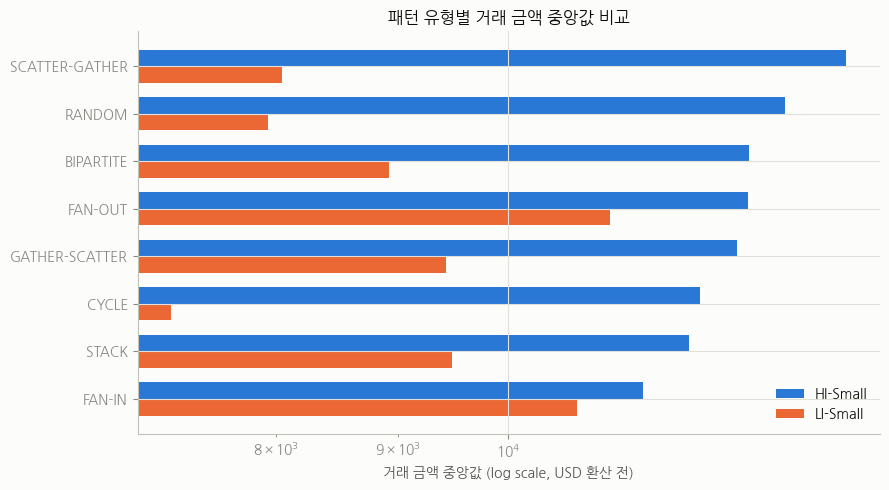

In [17]:
# 패턴 유형별 거래 금액 규모(중앙값) 비교
amount_by_pattern = {label: patterns_dfs[label].groupby("pattern_type")["Amount Paid"].median()
                      for label in WORLDS}
all_patterns_amt = sorted(
    set().union(*[s.index for s in amount_by_pattern.values()]),
    key=lambda p: -max(amount_by_pattern[l].get(p, 0) for l in WORLDS),
)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(all_patterns_amt))
width = 0.35
for i, label in enumerate(WORLDS):
    vals = [amount_by_pattern[label].get(p, np.nan) for p in all_patterns_amt]
    ax.barh(y + (i - 0.5) * width, vals, width, color=WORLD_COLOR[label], label=label)
ax.set_yticks(y)
ax.set_yticklabels(all_patterns_amt)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("거래 금액 중앙값 (log scale, USD 환산 전)")
ax.set_title("패턴 유형별 거래 금액 중앙값 비교")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 13. 요약

In [18]:
print("=" * 70)
print("HI-Small vs LI-Small EDA 요약")
print("=" * 70)
for label in WORLDS:
    df = dfs[label]
    rate = df["Is Laundering"].mean() * 100
    counts = df["Is Laundering"].value_counts().sort_index()
    imbalance = counts[0] / counts[1]
    top_fmt_rate = fmt_rate_by_world[label].sort_values(ascending=False)
    self_rate = flow_summaries[label].loc["동일 계좌(셀프)", "세탁비율"]
    cross_rate = flow_summaries[label].loc["타 은행 간", "세탁비율"]
    top_pattern = pattern_counts_by_world[label].sort_values(ascending=False)

    print(f"\n[{label}]")
    print(f"- 거래 건수: {len(df):,} / 계좌 수: {df['From Account'].nunique():,}")
    print(f"- 자금세탁 비율: {rate:.4f}% (정상:세탁 = {imbalance:,.0f}:1)")
    print(f"- 세탁 비율이 가장 높은 결제 수단: {top_fmt_rate.index[0]} ({top_fmt_rate.iloc[0]:.3f}%)")
    print(f"- 자금 흐름별 세탁 비율: 셀프이체 {self_rate:.4f}% vs 타행 간 {cross_rate:.4f}%")
    print(f"- 가장 많이 등장한 라운더링 패턴: {top_pattern.index[0]} ({top_pattern.iloc[0]:,}건)")
    print(f"- 계좌 최대 Out-degree: {degree_by_world[label]['out'].max():,} / "
          f"최대 In-degree: {degree_by_world[label]['in'].max():,}")

HI-Small vs LI-Small EDA 요약

[HI-Small]
- 거래 건수: 5,078,345 / 계좌 수: 496,995
- 자금세탁 비율: 0.1019% (정상:세탁 = 980:1)
- 세탁 비율이 가장 높은 결제 수단: ACH (0.746%)
- 자금 흐름별 세탁 비율: 셀프이체 0.0019% vs 타행 간 0.1157%
- 가장 많이 등장한 라운더링 패턴: GATHER-SCATTER (716건)
- 계좌 최대 Out-degree: 168,672 / 최대 In-degree: 1,084

[LI-Small]
- 거래 건수: 6,924,049 / 계좌 수: 681,281
- 자금세탁 비율: 0.0515% (정상:세탁 = 1,941:1)
- 세탁 비율이 가장 높은 결제 수단: ACH (0.328%)
- 자금 흐름별 세탁 비율: 셀프이체 0.0004% vs 타행 간 0.0581%
- 가장 많이 등장한 라운더링 패턴: SCATTER-GATHER (182건)
- 계좌 최대 Out-degree: 222,037 / 최대 In-degree: 1,553


In [27]:
trans_columns = ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
                  'Amount Received', 'Receiving Currency', 'Amount Paid',
                  'Payment Currency', 'Payment Format', 'Is Laundering']

def parse_patterns(path):
    records = []
    attempt_id = 0
    pattern_type = pattern_desc = None
    with open(path) as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith("BEGIN LAUNDERING ATTEMPT"):
                attempt_id += 1
                header = line.replace("BEGIN LAUNDERING ATTEMPT - ", "")
                if ":" in header:
                    pattern_type, pattern_desc = [x.strip() for x in header.split(":", 1)]
                else:
                    pattern_type, pattern_desc = header.strip(), ""
            elif line.startswith("END LAUNDERING ATTEMPT") or line.strip() == "":
                continue
            else:
                fields = line.split(",")
                if len(fields) == len(trans_columns):
                    row = dict(zip(trans_columns, fields))
                    row["attempt_id"] = attempt_id
                    row["pattern_type"] = pattern_type
                    row["pattern_desc"] = pattern_desc
                    records.append(row)
    return pd.DataFrame(records)


def load_trans(path):
    df = pd.read_csv(path)
    df = df.rename(columns={"Account": "From Account", "Account.1": "To Account"})
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df["date"] = df["Timestamp"].dt.date
    df["hour"] = df["Timestamp"].dt.hour

    same_account = (df["From Bank"] == df["To Bank"]) & (df["From Account"] == df["To Account"])
    same_bank_diff_account = (df["From Bank"] == df["To Bank"]) & (df["From Account"] != df["To Account"])
    cross_bank = df["From Bank"] != df["To Bank"]
    df["flow_type"] = np.select(
        [same_account, same_bank_diff_account, cross_bank],
        ["동일 계좌(셀프)", "동일 은행/타 계좌", "타 은행 간"],
        default="unknown",
    )
    return df


dfs, accounts_dfs, patterns_dfs = {}, {}, {}

for ratio in ["HI", "LI"]:
    label = f"{ratio}-Small"
    trans_path = catalog.query("ratio==@ratio and type=='Trans'")["path"].iloc[0]
    accounts_path = catalog.query("ratio==@ratio and type=='accounts'")["path"].iloc[0]
    patterns_path = catalog.query("ratio==@ratio and type=='Patterns'")["path"].iloc[0]

    dfs[label] = load_trans(trans_path)
    accounts_dfs[label] = pd.read_csv(accounts_path)
    patterns_dfs[label] = parse_patterns(patterns_path)
    patterns_dfs[label]["Amount Paid"] = patterns_dfs[label]["Amount Paid"].astype(float)

    print(f"{label}: trans={dfs[label].shape}, accounts={accounts_dfs[label].shape}, "
          f"patterns_rows={len(patterns_dfs[label]):,}")

HI-Small: trans=(5078345, 14), accounts=(518581, 5), patterns_rows=3,209
LI-Small: trans=(6924049, 14), accounts=(712688, 5), patterns_rows=1,023


{'HI-Small':                   Timestamp  From Bank From Account  To Bank To Account  Amount Received Receiving Currency   Amount Paid  \
 0       2022-09-01 00:20:00         10    8000EBD30       10  8000EBD30      3697.340000          US Dollar   3697.340000   
 1       2022-09-01 00:20:00       3208    8000F4580        1  8000F5340         0.010000          US Dollar      0.010000   
 2       2022-09-01 00:00:00       3209    8000F4670     3209  8000F4670     14675.570000          US Dollar  14675.570000   
 3       2022-09-01 00:02:00         12    8000F5030       12  8000F5030      2806.970000          US Dollar   2806.970000   
 4       2022-09-01 00:06:00         10    8000F5200       10  8000F5200     36682.970000          US Dollar  36682.970000   
 ...                     ...        ...          ...      ...        ...              ...                ...           ...   
 5078340 2022-09-10 23:57:00      54219    8148A6631   256398  8148A8711         0.154978            Bitco

In [29]:
for label in ["HI-Small", "LI-Small"]:
    adf = accounts_dfs[label]
    n_id = adf["Bank ID"].nunique()
    n_name = adf["Bank Name"].nunique()
    print(f"{label}: 고유 Bank ID = {n_id:,} / 고유 Bank Name = {n_name:,}")

HI-Small: 고유 Bank ID = 30,470 / 고유 Bank Name = 20,053
LI-Small: 고유 Bank ID = 41,815 / 고유 Bank Name = 27,652


In [30]:
for label in ["HI-Small", "LI-Small"]:
    adf = accounts_dfs[label]
    name_to_ids = adf.groupby("Bank Name")["Bank ID"].nunique()
    dup_name = name_to_ids[name_to_ids > 1]
    print(f"{label}: 같은 Bank Name에 여러 Bank ID가 매핑된 은행명 수 = {len(dup_name)}")

HI-Small: 같은 Bank Name에 여러 Bank ID가 매핑된 은행명 수 = 468
LI-Small: 같은 Bank Name에 여러 Bank ID가 매핑된 은행명 수 = 468


In [31]:
dup_names = {}
for label in ["HI-Small", "LI-Small"]:
    adf = accounts_dfs[label]
    n2i = adf.groupby("Bank Name")["Bank ID"].nunique()
    dup_names[label] = set(n2i[n2i > 1].index)

common = dup_names["HI-Small"] & dup_names["LI-Small"]
print("HI 중복이름 수:", len(dup_names["HI-Small"]))
print("LI 중복이름 수:", len(dup_names["LI-Small"]))
print("두 데이터셋 공통 중복이름 수:", len(common))
print("HI에만 있는 것:", len(dup_names["HI-Small"] - dup_names["LI-Small"]))
print("LI에만 있는 것:", len(dup_names["LI-Small"] - dup_names["HI-Small"]))
print("공통 중복이름 샘플 10개:", list(common)[:10])

HI 중복이름 수: 468
LI 중복이름 수: 468
두 데이터셋 공통 중복이름 수: 468
HI에만 있는 것: 0
LI에만 있는 것: 0
공통 중복이름 샘플 10개: ['Brook Federal Bank', 'Sappo Community Bank', 'Heath Bank', 'Savings Bank of Newport', 'Savings Bank of Albany', 'Regents Thrift', 'Brook Thrift', 'Capital Bancorp', 'First Bank of Denver', 'Savings Bank of Sacramento']


In [32]:
# 중복된 이름이 국가명 스타일인지 미국식 고유명인지 확인
is_country_style = {}
us_style_names = {}
for label in ["HI-Small", "LI-Small"]:
    adf = accounts_dfs[label]
    is_country_style[label] = adf["Bank Name"].str.match(r"^[A-Za-z]+ Bank #\d+$")
    us_style_names[label] = set(adf.loc[~is_country_style[label], "Bank Name"])

country_style_names_HI = set(accounts_dfs["HI-Small"].loc[is_country_style["HI-Small"], "Bank Name"])
print("중복이름 중 국가명 스타일 개수:", len(dup_names["HI-Small"] & country_style_names_HI))
print("중복이름 중 미국식 고유명 개수:", len(dup_names["HI-Small"] - country_style_names_HI))

중복이름 중 국가명 스타일 개수: 0
중복이름 중 미국식 고유명 개수: 468


In [33]:
# 미국식 고유은행명 풀이 HI ⊂ LI 관계인지 확인 (같은 템플릿 풀에서 뽑아 쓰는지)
print("HI 미국식 고유은행명 개수:", len(us_style_names["HI-Small"]))
print("LI 미국식 고유은행명 개수:", len(us_style_names["LI-Small"]))
overlap = us_style_names["HI-Small"] & us_style_names["LI-Small"]
print("HI/LI 공통 미국식 은행명 개수:", len(overlap))
print("HI가 LI의 부분집합인가:", us_style_names["HI-Small"].issubset(us_style_names["LI-Small"]))

HI 미국식 고유은행명 개수: 1036
LI 미국식 고유은행명 개수: 2168
HI/LI 공통 미국식 은행명 개수: 1036
HI가 LI의 부분집합인가: True


In [35]:
adf = accounts_dfs["HI-Small"]  # 확인할 데이터셋으로 교체

id_name_pairs = adf[["Bank ID", "Bank Name"]].drop_duplicates()

# 1) Bank ID는 같은데 Bank Name이 다른 경우
id_counts = id_name_pairs["Bank ID"].value_counts()
broken_id = id_counts[id_counts > 1]
print("Bank ID 같은데 Bank Name 다른 경우:", len(broken_id))
if len(broken_id) > 0:
    display(id_name_pairs[id_name_pairs["Bank ID"].isin(broken_id.index)].sort_values("Bank ID"))

# 2) Bank Name은 같은데 Bank ID가 다른 경우
name_counts = id_name_pairs["Bank Name"].value_counts()
broken_name = name_counts[name_counts > 1]
print("Bank Name 같은데 Bank ID 다른 경우:", len(broken_name))

Bank ID 같은데 Bank Name 다른 경우: 0
Bank Name 같은데 Bank ID 다른 경우: 468


In [36]:
adf = accounts_dfs["HI-Small"]  # 확인할 데이터셋으로 교체

id_name_pairs = adf[["Bank ID", "Bank Name"]].drop_duplicates()
name_counts = id_name_pairs["Bank Name"].value_counts()
dup_names = name_counts[name_counts > 1]

# 은행명별로 몇 개의 Bank ID를 갖는지 + 그 ID 목록
dup_detail = (
    id_name_pairs[id_name_pairs["Bank Name"].isin(dup_names.index)]
    .groupby("Bank Name")["Bank ID"]
    .agg(["nunique", lambda x: sorted(x.tolist())])
    .rename(columns={"nunique": "id_count", "<lambda_0>": "bank_ids"})
    .sort_values("id_count", ascending=False)
)

print("중복 은행명 총", len(dup_detail), "개")
pd.set_option("display.max_rows", 500)
dup_detail

중복 은행명 총 468 개


,id_count,bank_ids
Bank Name,,
First Bank of Miami,48,"[31363, 31908, 32109, 32514, 34545, 35282, 358..."
Bank of Billings,48,"[11904, 31001, 31995, 32235, 32449, 32963, 330..."
National Bank of Fairfield,47,"[3288, 3958, 3976, 31466, 31538, 31812, 32199,..."
National Bank of Los Angeles,46,"[3274, 3608, 3762, 26592, 31278, 32400, 34103,..."
National Bank of Sacramento,46,"[3904, 3985, 31985, 32273, 36645, 37280, 38287..."
Savings Bank of Newport,45,"[3593, 3948, 17246, 18819, 31438, 32486, 34354..."
National Bank of Miami,44,"[31192, 31617, 31894, 32107, 32146, 32997, 342..."
First Bank of the East,44,"[3784, 31082, 31542, 31769, 31802, 32153, 3238..."
First Bank of Danbury,44,"[3731, 5394, 17327, 34291, 34919, 35698, 35790..."


# 이슈 분석

## 1. 동일 계좌 송금 자금 세탁 건수 분석

In [67]:
# ============================================================
# 동일 계좌 자금세탁 거래 분석
#
# 사전 조건:
# - 기존 셀에서 catalog가 이미 생성되어 있어야 한다.
# - catalog에는 ratio, size, type, path 컬럼이 있어야 한다.
#
# 분석 내용:
# 1. HI-Small / LI-Small 동일 계좌 자금세탁 거래 추출
# 2. Patterns.txt의 attempt와 정확히 대응
# 3. GATHER-SCATTER 안에서 self-loop 계좌의 역할 분석
# 4. 앞뒤 거래 확인
# 5. attempt 그래프 시각화
# ============================================================

from pathlib import Path
from IPython.display import display

import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx


# ------------------------------------------------------------
# 1. 기존 catalog에서 파일 경로 가져오기
# ------------------------------------------------------------

SA_DATASETS = [
    "HI-Small",
    "LI-Small",
]


def sa_get_path(dataset_id, file_type):
    """
    기존 catalog에서 파일 경로를 가져온다.

    dataset_id:
        HI-Small
        LI-Small

    file_type:
        Trans
        accounts
        Patterns
    """
    ratio, size = dataset_id.split("-", 1)

    matched = catalog.loc[
        (catalog["ratio"] == ratio)
        & (catalog["size"].astype(str) == size)
        & (catalog["type"] == file_type),
        "path",
    ]

    if len(matched) == 0:
        raise FileNotFoundError(
            f"catalog에서 파일을 찾지 못했습니다: "
            f"{dataset_id}, {file_type}"
        )

    if len(matched) > 1:
        raise ValueError(
            f"catalog에 파일이 여러 개 있습니다: "
            f"{dataset_id}, {file_type}\n"
            f"{matched.tolist()}"
        )

    return matched.iloc[0]


print("[사용할 파일]")

for dataset_id in SA_DATASETS:
    print(f"\n{dataset_id}")
    print(
        "  Trans   :",
        sa_get_path(dataset_id, "Trans"),
    )
    print(
        "  Patterns:",
        sa_get_path(dataset_id, "Patterns"),
    )


[사용할 파일]

HI-Small
  Trans   : /workspace/money_laundry/datasets/HI-Small_Trans.csv
  Patterns: /workspace/money_laundry/datasets/HI-Small_Patterns.txt

LI-Small
  Trans   : /workspace/money_laundry/datasets/LI-Small_Trans.csv
  Patterns: /workspace/money_laundry/datasets/LI-Small_Patterns.txt


In [68]:
# ------------------------------------------------------------
# 2. Bank ID 및 계좌 키 함수
# ------------------------------------------------------------

def sa_canon_bank(value):
    """
    선행 0만 다른 Bank ID를 비교하기 위한 정규화.

    예:
        0048309 -> 48309
        00012   -> 12
    """
    text = str(value).strip()
    stripped = text.lstrip("0")

    return stripped or "0"


def sa_account_key(
    dataset_id,
    bank_id,
    account_number,
):
    """
    데이터셋 간 계좌 ID 충돌을 막는 복합 계좌 키.

    예:
        HI-Small|48309|811C599A0
    """
    return (
        f"{dataset_id}|"
        f"{sa_canon_bank(bank_id)}|"
        f"{str(account_number).strip()}"
    )

In [69]:
# ------------------------------------------------------------
# 3. Patterns.txt 파서
# ------------------------------------------------------------

SA_PATTERN_COLUMNS = [
    "Timestamp",
    "From Bank",
    "From Account",
    "To Bank",
    "To Account",
    "Amount Received",
    "Receiving Currency",
    "Amount Paid",
    "Payment Currency",
    "Payment Format",
    "Is Laundering",
]


def sa_parse_patterns(
    path,
    dataset_id,
):
    """
    Patterns.txt의 BEGIN~END 블록을 attempt로 파싱한다.

    추가되는 주요 컬럼:
    - attempt_id
    - pattern_type
    - pattern_desc
    - attempt_edge_index
    - src
    - dst
    - is_self_loop
    """
    records = []

    attempt_id = 0
    attempt_edge_index = 0
    pattern_row_index = 0

    pattern_type = None
    pattern_desc = None

    with open(
        path,
        encoding="utf-8",
    ) as file:
        for raw_line in file:
            line = raw_line.strip()

            if not line:
                continue

            if line.startswith(
                "BEGIN LAUNDERING ATTEMPT"
            ):
                attempt_id += 1
                attempt_edge_index = 0

                header = line.replace(
                    "BEGIN LAUNDERING ATTEMPT - ",
                    "",
                    1,
                )

                (
                    pattern_type,
                    _,
                    pattern_desc,
                ) = header.partition(":")

                pattern_type = pattern_type.strip()
                pattern_desc = pattern_desc.strip()

                continue

            if line.startswith(
                "END LAUNDERING ATTEMPT"
            ):
                continue

            fields = next(
                csv.reader([line])
            )

            if len(fields) != 11:
                raise ValueError(
                    "Patterns 행의 컬럼 수가 "
                    f"11이 아닙니다: {line[:200]}"
                )

            row = dict(
                zip(
                    SA_PATTERN_COLUMNS,
                    fields,
                )
            )

            row.update({
                "dataset_id": dataset_id,
                "attempt_id": attempt_id,
                "pattern_type": pattern_type,
                "pattern_desc": pattern_desc,
                "attempt_edge_index": (
                    attempt_edge_index
                ),
                "pattern_row_index": (
                    pattern_row_index
                ),
            })

            records.append(row)

            attempt_edge_index += 1
            pattern_row_index += 1

    result = pd.DataFrame(records)

    result["Timestamp"] = pd.to_datetime(
        result["Timestamp"],
        format="%Y/%m/%d %H:%M",
    )

    result["Amount Received"] = pd.to_numeric(
        result["Amount Received"]
    )

    result["Amount Paid"] = pd.to_numeric(
        result["Amount Paid"]
    )

    result["Is Laundering"] = (
        pd.to_numeric(
            result["Is Laundering"]
        )
        .astype("int8")
    )

    result["from_bank_canon"] = (
        result["From Bank"]
        .map(sa_canon_bank)
    )

    result["to_bank_canon"] = (
        result["To Bank"]
        .map(sa_canon_bank)
    )

    result["src"] = [
        sa_account_key(
            dataset_id,
            bank,
            account,
        )
        for bank, account
        in zip(
            result["From Bank"],
            result["From Account"],
        )
    ]

    result["dst"] = [
        sa_account_key(
            dataset_id,
            bank,
            account,
        )
        for bank, account
        in zip(
            result["To Bank"],
            result["To Account"],
        )
    ]

    result["is_self_loop"] = (
        result["src"]
        == result["dst"]
    )

    return result


In [70]:
# ------------------------------------------------------------
# 4. Trans에서 동일 계좌 자금세탁 거래 추출
# ------------------------------------------------------------

def sa_load_self_laundering(
    dataset_id,
    chunksize=1_000_000,
):
    """
    Trans.csv를 chunk 단위로 읽어서 다음 조건을 추출한다.

    - Is Laundering == 1
    - canonical From Bank == canonical To Bank
    - From Account == To Account
    """
    trans_path = sa_get_path(
        dataset_id,
        "Trans",
    )

    usecols = [
        "Timestamp",
        "From Bank",
        "Account",
        "To Bank",
        "Account.1",
        "Amount Received",
        "Receiving Currency",
        "Amount Paid",
        "Payment Currency",
        "Payment Format",
        "Is Laundering",
    ]

    dtype = {
        "Timestamp": "string",
        "From Bank": "string",
        "Account": "string",
        "To Bank": "string",
        "Account.1": "string",
        "Receiving Currency": "string",
        "Payment Currency": "string",
        "Payment Format": "string",
        "Is Laundering": "int8",
    }

    selected_parts = []
    row_offset = 0

    for chunk in pd.read_csv(
        trans_path,
        usecols=usecols,
        dtype=dtype,
        chunksize=chunksize,
    ):
        chunk = chunk.rename(
            columns={
                "Account": "From Account",
                "Account.1": "To Account",
            }
        )

        # 원본 Trans 안에서의 행 위치
        chunk["trans_row_index"] = np.arange(
            row_offset,
            row_offset + len(chunk),
        )

        row_offset += len(chunk)

        chunk["from_bank_canon"] = (
            chunk["From Bank"]
            .map(sa_canon_bank)
        )

        chunk["to_bank_canon"] = (
            chunk["To Bank"]
            .map(sa_canon_bank)
        )

        is_self_laundering = (
            chunk["Is Laundering"].eq(1)
            & chunk["from_bank_canon"].eq(
                chunk["to_bank_canon"]
            )
            & chunk["From Account"].eq(
                chunk["To Account"]
            )
        )

        selected = chunk.loc[
            is_self_laundering
        ].copy()

        if not selected.empty:
            selected_parts.append(selected)

    if not selected_parts:
        return pd.DataFrame()

    result = pd.concat(
        selected_parts,
        ignore_index=True,
    )

    result["dataset_id"] = dataset_id

    result["Timestamp"] = pd.to_datetime(
        result["Timestamp"],
        format="%Y/%m/%d %H:%M",
    )

    result["src"] = [
        sa_account_key(
            dataset_id,
            bank,
            account,
        )
        for bank, account
        in zip(
            result["From Bank"],
            result["From Account"],
        )
    ]

    result["dst"] = [
        sa_account_key(
            dataset_id,
            bank,
            account,
        )
        for bank, account
        in zip(
            result["To Bank"],
            result["To Account"],
        )
    ]

    result["is_self_loop"] = (
        result["src"]
        == result["dst"]
    )

    return result

In [71]:
# ------------------------------------------------------------
# 5. HI-Small / LI-Small 데이터 로드
# ------------------------------------------------------------

sa_pattern_frames = []
sa_self_frames = []

for dataset_id in SA_DATASETS:
    print(
        f"\n[{dataset_id}] 처리 중..."
    )

    patterns_path = sa_get_path(
        dataset_id,
        "Patterns",
    )

    pattern_part = sa_parse_patterns(
        patterns_path,
        dataset_id,
    )

    self_part = sa_load_self_laundering(
        dataset_id,
        chunksize=1_000_000,
    )

    print(
        "  Patterns 거래:",
        f"{len(pattern_part):,}건",
    )

    print(
        "  동일 계좌 자금세탁 거래:",
        f"{len(self_part):,}건",
    )

    sa_pattern_frames.append(
        pattern_part
    )

    sa_self_frames.append(
        self_part
    )


sa_patterns = pd.concat(
    sa_pattern_frames,
    ignore_index=True,
)

sa_self_transactions = pd.concat(
    sa_self_frames,
    ignore_index=True,
)


print("\n[동일 계좌 자금세탁 거래]")

display(
    sa_self_transactions[
        [
            "dataset_id",
            "trans_row_index",
            "Timestamp",
            "From Bank",
            "From Account",
            "To Bank",
            "To Account",
            "Amount Paid",
            "Payment Currency",
            "Payment Format",
            "Is Laundering",
        ]
    ]
)




[HI-Small] 처리 중...
  Patterns 거래: 3,209건
  동일 계좌 자금세탁 거래: 11건

[LI-Small] 처리 중...
  Patterns 거래: 1,023건
  동일 계좌 자금세탁 거래: 3건

[동일 계좌 자금세탁 거래]


,dataset_id,trans_row_index,Timestamp,From Bank,From Account,To Bank,To Account,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,HI-Small,318130,2022-09-04 05:03:00,0048309,811C599A0,0048309,811C599A0,48649.42,Saudi Riyal,ACH,1
1,HI-Small,887448,2022-09-01 14:04:00,015231,80266F880,015231,80266F880,14998.24,Euro,ACH,1
2,HI-Small,1982464,2022-09-03 19:55:00,015231,80266F880,015231,80266F880,4895.52,Euro,ACH,1
3,HI-Small,1984629,2022-09-04 21:37:00,0150240,812D22980,0150240,812D22980,71726.48,Saudi Riyal,ACH,1
4,HI-Small,2616583,2022-09-05 15:41:00,023691,8021353D0,023691,8021353D0,13178.60,Euro,ACH,1
5,HI-Small,2757791,2022-09-09 09:08:00,0048309,811C599A0,0048309,811C599A0,47970.16,Saudi Riyal,ACH,1
6,HI-Small,3006137,2022-09-06 23:04:00,0119,812A09CF0,0119,812A09CF0,30855.39,Saudi Riyal,ACH,1
7,HI-Small,3240081,2022-09-10 23:17:00,0119,811C597B0,0119,811C597B0,14144807.18,Saudi Riyal,ACH,1
8,HI-Small,3732502,2022-09-11 05:36:00,0048309,811C599A0,0048309,811C599A0,52436.24,Saudi Riyal,ACH,1
9,HI-Small,4958161,2022-09-17 17:23:00,0118,811B6E170,0118,811B6E170,11868.44,Saudi Riyal,ACH,1


In [72]:
# ------------------------------------------------------------
# 6. Trans와 Patterns 정확 대응
# ------------------------------------------------------------

SA_JOIN_COLUMNS = [
    "dataset_id",
    "Timestamp",
    "from_bank_canon",
    "From Account",
    "to_bank_canon",
    "To Account",
    "Amount Received",
    "Receiving Currency",
    "Amount Paid",
    "Payment Currency",
    "Payment Format",
    "Is Laundering",
]


# 완전히 같은 거래가 중복된 경우를 위한 occurrence
sa_patterns["key_occurrence"] = (
    sa_patterns
    .groupby(
        SA_JOIN_COLUMNS,
        dropna=False,
    )
    .cumcount()
)

sa_self_transactions["key_occurrence"] = (
    sa_self_transactions
    .groupby(
        SA_JOIN_COLUMNS,
        dropna=False,
    )
    .cumcount()
)


sa_self_detail = sa_self_transactions.merge(
    sa_patterns[
        SA_JOIN_COLUMNS
        + [
            "key_occurrence",
            "attempt_id",
            "pattern_type",
            "pattern_desc",
            "attempt_edge_index",
            "pattern_row_index",
        ]
    ],
    on=(
        SA_JOIN_COLUMNS
        + ["key_occurrence"]
    ),
    how="left",
    validate="one_to_one",
)


sa_summary = (
    sa_self_detail
    .groupby("dataset_id")
    .agg(
        self_laundering_transactions=(
            "trans_row_index",
            "size",
        ),
        matched_to_patterns=(
            "attempt_id",
            "count",
        ),
        unique_accounts=(
            "src",
            "nunique",
        ),
        unique_attempts=(
            "attempt_id",
            "nunique",
        ),
        payment_formats=(
            "Payment Format",
            lambda values: ", ".join(
                sorted(values.unique())
            ),
        ),
        pattern_types=(
            "pattern_type",
            lambda values: ", ".join(
                sorted(
                    values
                    .dropna()
                    .unique()
                )
            ),
        ),
    )
    .reset_index()
)


print("\n[Patterns 대응 결과]")

display(sa_summary)


# 현재 데이터에 대한 검증
assert sa_self_detail[
    "attempt_id"
].notna().all(), (
    "Patterns와 대응하지 않는 동일 계좌 "
    "자금세탁 거래가 있습니다."
)

assert set(
    sa_self_detail["Payment Format"]
) == {"ACH"}

assert set(
    sa_self_detail["pattern_type"]
) == {"GATHER-SCATTER"}

assert len(
    sa_self_detail.query(
        "dataset_id == 'HI-Small'"
    )
) == 11

assert len(
    sa_self_detail.query(
        "dataset_id == 'LI-Small'"
    )
) == 3


print(
    "PASS: 14건 모두 Patterns와 대응하며, "
    "모두 ACH · GATHER-SCATTER입니다."
)


# self_laundering_transactions	송신 계좌와 수신 계좌가 동일하면서 자금세탁으로 라벨링된 거래 수
# matched_to_patterns	그 거래 중 Patterns.txt의 특정 attempt 거래와 정확히 대응된 수
# unique_accounts	해당 거래에 등장한 서로 다른 동일 계좌 수
# unique_attempts	해당 거래들이 포함된 서로 다른 자금세탁 attempt 수


[Patterns 대응 결과]


,dataset_id,self_laundering_transactions,matched_to_patterns,unique_accounts,unique_attempts,payment_formats,pattern_types
0,HI-Small,11,11,7,11,ACH,GATHER-SCATTER
1,LI-Small,3,3,3,3,ACH,GATHER-SCATTER


PASS: 14건 모두 Patterns와 대응하며, 모두 ACH · GATHER-SCATTER입니다.


In [73]:
# ------------------------------------------------------------
# 7. self-loop를 제외한 계좌 역할 분류
# ------------------------------------------------------------

def sa_classify_role(
    incoming_count,
    outgoing_count,
):
    """
    self-loop를 제거하고 남은 거래만으로
    해당 계좌의 역할을 분류한다.
    """
    if (
        incoming_count > 0
        and outgoing_count > 0
    ):
        return "INTERMEDIARY_OR_HUB"

    if outgoing_count > 0:
        return "UPSTREAM_SOURCE"

    if incoming_count > 0:
        return "DOWNSTREAM_SINK"

    return "ISOLATED_SELF_LOOP"


sa_diagnostic_rows = []
sa_neighbor_frames = []


for case_id, tx in (
    sa_self_detail
    .reset_index(drop=True)
    .iterrows()
):
    attempt = (
        sa_patterns[
            (
                sa_patterns["dataset_id"]
                == tx["dataset_id"]
            )
            & (
                sa_patterns["attempt_id"]
                == tx["attempt_id"]
            )
        ]
        .sort_values(
            "attempt_edge_index"
        )
        .copy()
    )

    focus_node = tx["src"]

    # self-loop가 아닌 실제 계좌 간 edge
    nonself_edges = attempt[
        ~attempt["is_self_loop"]
    ].copy()

    incoming_edges = nonself_edges[
        nonself_edges["dst"]
        == focus_node
    ]

    outgoing_edges = nonself_edges[
        nonself_edges["src"]
        == focus_node
    ]

    counterparties = (
        set(incoming_edges["src"])
        | set(outgoing_edges["dst"])
    )

    graph_without_self = nx.DiGraph()

    graph_without_self.add_edges_from(
        zip(
            nonself_edges["src"],
            nonself_edges["dst"],
        )
    )

    component_size = 0

    if focus_node in graph_without_self:
        component_size = len(
            nx.node_connected_component(
                graph_without_self.to_undirected(),
                focus_node,
            )
        )

    edge_index = int(
        tx["attempt_edge_index"]
    )

    role = sa_classify_role(
        len(incoming_edges),
        len(outgoing_edges),
    )

    sa_diagnostic_rows.append({
        "case_id": case_id,
        "dataset_id": tx["dataset_id"],
        "trans_row_index": int(
            tx["trans_row_index"]
        ),
        "Timestamp": tx["Timestamp"],
        "account_node": focus_node,
        "amount_paid": tx["Amount Paid"],
        "currency": tx["Payment Currency"],
        "payment_format": tx["Payment Format"],
        "attempt_id": int(
            tx["attempt_id"]
        ),
        "pattern_type": tx["pattern_type"],

        # attempt 전체 구조
        "attempt_edges": len(attempt),
        "attempt_nodes": len(
            set(attempt["src"])
            | set(attempt["dst"])
        ),
        "attempt_self_loops": int(
            attempt["is_self_loop"].sum()
        ),

        # self-loop의 블록 내 위치
        "attempt_edge_index": edge_index,
        "attempt_position_pct": (
            100
            * edge_index
            / max(
                len(attempt) - 1,
                1,
            )
        ),

        # self-loop를 제외한 계좌 역할
        "nonself_in_edges_of_account": (
            len(incoming_edges)
        ),
        "nonself_out_edges_of_account": (
            len(outgoing_edges)
        ),
        "nonself_counterparties": (
            len(counterparties)
        ),
        "account_role_without_self_loop": (
            role
        ),

        "node_in_nonself_graph": (
            focus_node
            in graph_without_self
        ),
        "weak_component_size_without_self_loop": (
            component_size
        ),

        # self-loop는 새로운 계좌에 도달하지 않는다.
        "self_loop_adds_reachability": False,
    })

    # 분석 대상 앞뒤 2개 edge
    neighbor_edges = attempt[
        attempt[
            "attempt_edge_index"
        ].between(
            max(0, edge_index - 2),
            edge_index + 2,
        )
    ].copy()

    neighbor_edges["case_id"] = case_id
    neighbor_edges[
        "focus_edge_index"
    ] = edge_index

    neighbor_edges[
        "relative_position"
    ] = (
        neighbor_edges[
            "attempt_edge_index"
        ]
        - edge_index
    )

    sa_neighbor_frames.append(
        neighbor_edges
    )


sa_diagnostics = pd.DataFrame(
    sa_diagnostic_rows
)

sa_neighbor_edges = pd.concat(
    sa_neighbor_frames,
    ignore_index=True,
)


SA_DIAGNOSTIC_COLUMNS = [
    "case_id",
    "dataset_id",
    "Timestamp",
    "account_node",
    "amount_paid",
    "currency",
    "attempt_id",
    "attempt_edges",
    "attempt_nodes",
    "attempt_self_loops",
    "attempt_edge_index",
    "nonself_in_edges_of_account",
    "nonself_out_edges_of_account",
    "nonself_counterparties",
    "account_role_without_self_loop",
    "weak_component_size_without_self_loop",
]


print("\n[14건 상세 진단]")

display(
    sa_diagnostics[
        SA_DIAGNOSTIC_COLUMNS
    ]
)

# attempt_id	Patterns.txt 안에서 자금세탁 attempt를 구분하기 위해 순서대로 부여한 번호
# attempt_edges	해당 attempt에 포함된 전체 거래 수
# attempt_nodes	해당 attempt에 등장한 서로 다른 계좌 수
# attempt_self_loops	attempt 안에서 송신·수신 계좌가 동일한 거래 수
# attempt_edge_index	분석 대상 self-loop가 attempt 블록에서 몇 번째 거래인지 나타내는 0부터 시작하는 순번
# nonself_in_edges_of_account	self-loop를 제외하고 분석 대상 계좌로 들어온 거래 수
# nonself_out_edges_of_account	self-loop를 제외하고 분석 대상 계좌에서 나간 거래 수
# nonself_counterparties	self-loop를 제외하고 분석 대상 계좌와 거래한 고유 상대 계좌 수
# account_role_without_self_loop	self-loop를 제거했을 때 분석 대상 계좌가 attempt에서 맡는 역할
# weak_component_size_without_self_loop


[14건 상세 진단]


,case_id,dataset_id,Timestamp,account_node,amount_paid,currency,attempt_id,attempt_edges,attempt_nodes,attempt_self_loops,attempt_edge_index,nonself_in_edges_of_account,nonself_out_edges_of_account,nonself_counterparties,account_role_without_self_loop,weak_component_size_without_self_loop
0,0,HI-Small,2022-09-04 05:03:00,HI-Small|48309|811C599A0,48649.42,Saudi Riyal,3,5,4,1,3,3,1,3,INTERMEDIARY_OR_HUB,4
1,1,HI-Small,2022-09-01 14:04:00,HI-Small|15231|80266F880,14998.24,Euro,35,2,2,1,1,1,0,1,DOWNSTREAM_SINK,2
2,2,HI-Small,2022-09-03 19:55:00,HI-Small|15231|80266F880,4895.52,Euro,98,2,2,1,1,1,0,1,DOWNSTREAM_SINK,2
3,3,HI-Small,2022-09-04 21:37:00,HI-Small|150240|812D22980,71726.48,Saudi Riyal,100,6,4,1,3,3,2,3,INTERMEDIARY_OR_HUB,4
4,4,HI-Small,2022-09-05 15:41:00,HI-Small|23691|8021353D0,13178.60,Euro,171,2,2,1,1,1,0,1,DOWNSTREAM_SINK,2
5,5,HI-Small,2022-09-09 09:08:00,HI-Small|48309|811C599A0,47970.16,Saudi Riyal,183,4,3,1,3,2,1,2,INTERMEDIARY_OR_HUB,3
6,6,HI-Small,2022-09-06 23:04:00,HI-Small|119|812A09CF0,30855.39,Saudi Riyal,202,2,2,1,1,1,0,1,DOWNSTREAM_SINK,2
7,7,HI-Small,2022-09-10 23:17:00,HI-Small|119|811C597B0,14144807.18,Saudi Riyal,222,5,3,1,3,2,2,2,INTERMEDIARY_OR_HUB,3
8,8,HI-Small,2022-09-11 05:36:00,HI-Small|48309|811C599A0,52436.24,Saudi Riyal,259,6,4,1,3,3,2,3,INTERMEDIARY_OR_HUB,4
9,9,HI-Small,2022-09-17 17:23:00,HI-Small|118|811B6E170,11868.44,Saudi Riyal,345,15,14,1,14,2,12,13,INTERMEDIARY_OR_HUB,14


In [74]:
# ------------------------------------------------------------
# 8. 역할별 결과 요약
# ------------------------------------------------------------

sa_role_summary = (
    sa_diagnostics[
        "account_role_without_self_loop"
    ]
    .value_counts(dropna=False)
    .rename_axis("role")
    .reset_index(name="transactions")
)


print(
    "\n[self-loop를 제외했을 때 "
    "해당 계좌의 역할]"
)

display(sa_role_summary)


sa_isolated_count = int(
    sa_diagnostics[
        "account_role_without_self_loop"
    ]
    .eq("ISOLATED_SELF_LOOP")
    .sum()
)

sa_connected_count = (
    len(sa_diagnostics)
    - sa_isolated_count
)


print(
    "다른 non-self edge에도 참여하는 계좌:",
    f"{sa_connected_count}건",
)

print(
    "self-loop로만 등장하는 고립 계좌:",
    f"{sa_isolated_count}건",
)


print(
    "\n역할 의미:\n"
    "- INTERMEDIARY_OR_HUB: 다른 계좌에서 받고 다른 계좌로 보냄\n"
    "- DOWNSTREAM_SINK: 다른 계좌에서 받지만 다른 계좌로 보내지 않음\n"
    "- UPSTREAM_SOURCE: 다른 계좌로 보내지만 들어오는 거래가 없음\n"
    "- ISOLATED_SELF_LOOP: 해당 attempt에 self-loop만 존재"
)


[self-loop를 제외했을 때 해당 계좌의 역할]


,role,transactions
0,INTERMEDIARY_OR_HUB,7
1,DOWNSTREAM_SINK,6
2,ISOLATED_SELF_LOOP,1


다른 non-self edge에도 참여하는 계좌: 13건
self-loop로만 등장하는 고립 계좌: 1건

역할 의미:
- INTERMEDIARY_OR_HUB: 다른 계좌에서 받고 다른 계좌로 보냄
- DOWNSTREAM_SINK: 다른 계좌에서 받지만 다른 계좌로 보내지 않음
- UPSTREAM_SOURCE: 다른 계좌로 보내지만 들어오는 거래가 없음
- ISOLATED_SELF_LOOP: 해당 attempt에 self-loop만 존재


In [75]:
# ------------------------------------------------------------
# 9. 개별 사례 앞뒤 거래 확인 함수
# ------------------------------------------------------------

def sa_show_case(case_id=0):
    case = sa_diagnostics[
        sa_diagnostics["case_id"]
        == case_id
    ]

    if case.empty:
        raise IndexError(
            f"case_id={case_id}가 없습니다."
        )

    print(
        f"[case_id={case_id}: "
        "동일 계좌 자금세탁 거래]"
    )

    display(
        case[
            SA_DIAGNOSTIC_COLUMNS
        ]
    )

    print(
        "[Patterns 블록에서 "
        "분석 대상 앞뒤 2개 거래]"
    )

    neighbor_view = (
        sa_neighbor_edges[
            sa_neighbor_edges["case_id"]
            == case_id
        ][
            [
                "relative_position",
                "attempt_edge_index",
                "Timestamp",
                "src",
                "dst",
                "Amount Paid",
                "Payment Currency",
                "Payment Format",
                "is_self_loop",
            ]
        ]
        .sort_values(
            "attempt_edge_index"
        )
    )

    display(neighbor_view)

    print(
        "relative_position=0인 행이 "
        "분석 대상 self-loop입니다."
    )

    return neighbor_view


# 첫 번째 사례 확인
sa_show_case(9)

[case_id=9: 동일 계좌 자금세탁 거래]


,case_id,dataset_id,Timestamp,account_node,amount_paid,currency,attempt_id,attempt_edges,attempt_nodes,attempt_self_loops,attempt_edge_index,nonself_in_edges_of_account,nonself_out_edges_of_account,nonself_counterparties,account_role_without_self_loop,weak_component_size_without_self_loop
9,9,HI-Small,2022-09-17 17:23:00,HI-Small|118|811B6E170,11868.44,Saudi Riyal,345,15,14,1,14,2,12,13,INTERMEDIARY_OR_HUB,14


[Patterns 블록에서 분석 대상 앞뒤 2개 거래]


,relative_position,attempt_edge_index,Timestamp,src,dst,Amount Paid,Payment Currency,Payment Format,is_self_loop
29,-2,12,2022-09-17 05:57:00,HI-Small|118|811B6E170,HI-Small|121|8000E1590,40089.33,Saudi Riyal,ACH,False
30,-1,13,2022-09-17 09:39:00,HI-Small|118|811B6E170,HI-Small|119|811DCA9B0,13001.02,Saudi Riyal,ACH,False
31,0,14,2022-09-17 17:23:00,HI-Small|118|811B6E170,HI-Small|118|811B6E170,11868.44,Saudi Riyal,ACH,True


relative_position=0인 행이 분석 대상 self-loop입니다.


,relative_position,attempt_edge_index,Timestamp,src,dst,Amount Paid,Payment Currency,Payment Format,is_self_loop
29,-2,12,2022-09-17 05:57:00,HI-Small|118|811B6E170,HI-Small|121|8000E1590,40089.33,Saudi Riyal,ACH,False
30,-1,13,2022-09-17 09:39:00,HI-Small|118|811B6E170,HI-Small|119|811DCA9B0,13001.02,Saudi Riyal,ACH,False
31,0,14,2022-09-17 17:23:00,HI-Small|118|811B6E170,HI-Small|118|811B6E170,11868.44,Saudi Riyal,ACH,True


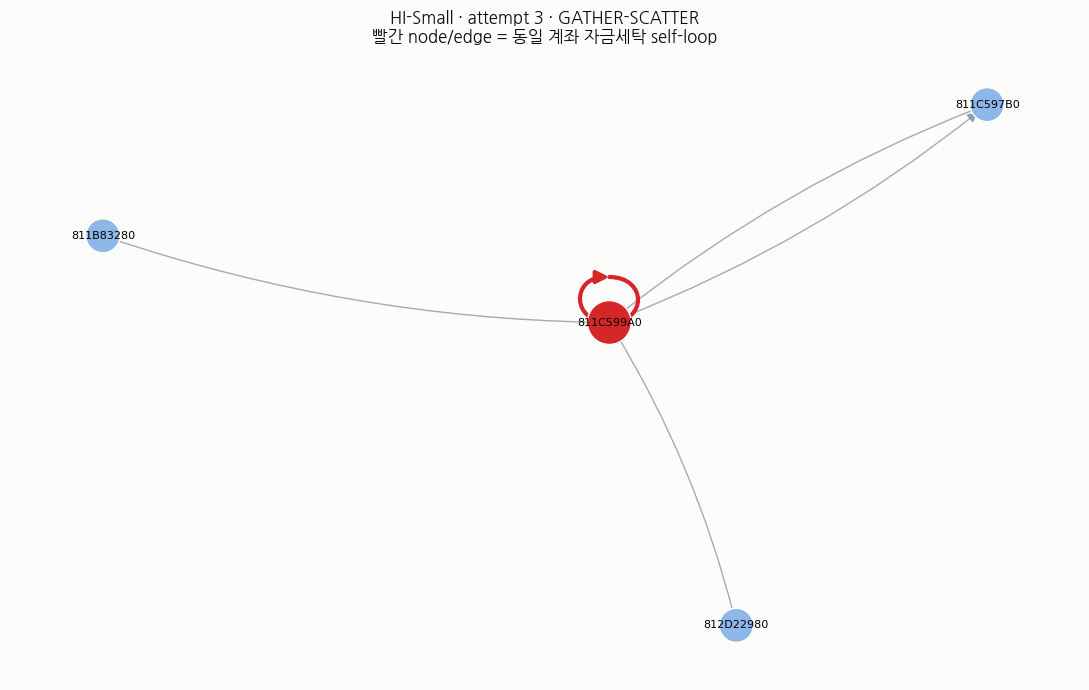

,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,dataset_id,attempt_id,pattern_type,pattern_desc,attempt_edge_index,pattern_row_index,from_bank_canon,to_bank_canon,src,dst,is_self_loop,key_occurrence
26,2022-09-01 00:04:00,0119,811C597B0,0048309,811C599A0,34254.65,Saudi Riyal,34254.65,Saudi Riyal,ACH,1,HI-Small,3,GATHER-SCATTER,Max 3-degree Fan-In,0,26,119,48309,HI-Small|119|811C597B0,HI-Small|48309|811C599A0,False,0
27,2022-09-01 19:27:00,0150240,812D22980,0048309,811C599A0,5971.98,Saudi Riyal,5971.98,Saudi Riyal,ACH,1,HI-Small,3,GATHER-SCATTER,Max 3-degree Fan-In,1,27,150240,48309,HI-Small|150240|812D22980,HI-Small|48309|811C599A0,False,0
28,2022-09-04 05:06:00,0222,811B83280,0048309,811C599A0,50445.58,Saudi Riyal,50445.58,Saudi Riyal,ACH,1,HI-Small,3,GATHER-SCATTER,Max 3-degree Fan-In,2,28,222,48309,HI-Small|222|811B83280,HI-Small|48309|811C599A0,False,0
29,2022-09-04 05:03:00,0048309,811C599A0,0048309,811C599A0,48649.42,Saudi Riyal,48649.42,Saudi Riyal,ACH,1,HI-Small,3,GATHER-SCATTER,Max 3-degree Fan-In,3,29,48309,48309,HI-Small|48309|811C599A0,HI-Small|48309|811C599A0,True,0
30,2022-09-04 14:59:00,0048309,811C599A0,0119,811C597B0,64379.45,Saudi Riyal,64379.45,Saudi Riyal,ACH,1,HI-Small,3,GATHER-SCATTER,Max 3-degree Fan-In,4,30,48309,119,HI-Small|48309|811C599A0,HI-Small|119|811C597B0,False,0


In [76]:
# ------------------------------------------------------------
# 10. attempt 그래프 시각화
# ------------------------------------------------------------

def sa_plot_attempt(
    case_id=0,
    seed=42,
    figsize=(11, 7),
):
    tx = (
        sa_self_detail
        .reset_index(drop=True)
        .iloc[case_id]
    )

    attempt = (
        sa_patterns[
            (
                sa_patterns["dataset_id"]
                == tx["dataset_id"]
            )
            & (
                sa_patterns["attempt_id"]
                == tx["attempt_id"]
            )
        ]
        .sort_values(
            "attempt_edge_index"
        )
        .copy()
    )

    graph = nx.MultiDiGraph()

    for _, edge in attempt.iterrows():
        graph.add_edge(
            edge["src"],
            edge["dst"],
            is_self_loop=bool(
                edge["is_self_loop"]
            ),
            amount=edge["Amount Paid"],
            currency=edge[
                "Payment Currency"
            ],
            edge_index=int(
                edge["attempt_edge_index"]
            ),
        )

    # 시각화 위치는 방향을 제거한 구조로 계산
    layout_graph = nx.Graph(graph)

    position = nx.spring_layout(
        layout_graph,
        seed=seed,
        k=1.2 / np.sqrt(
            max(len(graph), 1)
        ),
    )

    focus_node = tx["src"]

    node_colors = [
        "#d62728"
        if node == focus_node
        else "#8db7e8"
        for node in graph.nodes
    ]

    node_sizes = [
        1_000
        if node == focus_node
        else 600
        for node in graph.nodes
    ]

    normal_edges = [
        (source, target, key)
        for (
            source,
            target,
            key,
            edge_data,
        )
        in graph.edges(
            keys=True,
            data=True,
        )
        if not edge_data[
            "is_self_loop"
        ]
    ]

    self_loop_edges = [
        (source, target, key)
        for (
            source,
            target,
            key,
            edge_data,
        )
        in graph.edges(
            keys=True,
            data=True,
        )
        if edge_data[
            "is_self_loop"
        ]
    ]

    plt.figure(
        figsize=figsize
    )

    nx.draw_networkx_nodes(
        graph,
        position,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="white",
    )

    nx.draw_networkx_labels(
        graph,
        position,
        labels={
            node: node.split("|")[-1]
            for node in graph.nodes
        },
        font_size=8,
    )

    nx.draw_networkx_edges(
        graph,
        position,
        edgelist=normal_edges,
        edge_color="#718096",
        alpha=0.65,
        arrows=True,
        arrowsize=15,
        connectionstyle=(
            "arc3,rad=0.08"
        ),
    )

    nx.draw_networkx_edges(
        graph,
        position,
        edgelist=self_loop_edges,
        edge_color="#d62728",
        width=3,
        arrows=True,
        arrowsize=18,
        connectionstyle=(
            "arc3,rad=0.35"
        ),
    )

    plt.title(
        f"{tx['dataset_id']} · "
        f"attempt {int(tx['attempt_id'])} · "
        f"{tx['pattern_type']}\n"
        "빨간 node/edge = "
        "동일 계좌 자금세탁 self-loop"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return attempt


# 첫 번째 사례 시각화
sa_plot_attempt(0)

,case_id,dataset_id,trans_row_index,Timestamp,account_node,amount_paid,currency,payment_format,attempt_id,pattern_type,attempt_edges,attempt_nodes,attempt_self_loops,attempt_edge_index,attempt_position_pct,nonself_in_edges_of_account,nonself_out_edges_of_account,nonself_counterparties,account_role_without_self_loop,node_in_nonself_graph,weak_component_size_without_self_loop,self_loop_adds_reachability
11,11,LI-Small,2813351,2022-09-03 08:56:00,LI-Small|115|81522E390,40877.23,Shekel,ACH,41,GATHER-SCATTER,1,1,1,0,0.0,0,0,0,ISOLATED_SELF_LOOP,False,0,False


[case_id=11: 동일 계좌 자금세탁 거래]


,case_id,dataset_id,Timestamp,account_node,amount_paid,currency,attempt_id,attempt_edges,attempt_nodes,attempt_self_loops,attempt_edge_index,nonself_in_edges_of_account,nonself_out_edges_of_account,nonself_counterparties,account_role_without_self_loop,weak_component_size_without_self_loop
11,11,LI-Small,2022-09-03 08:56:00,LI-Small|115|81522E390,40877.23,Shekel,41,1,1,1,0,0,0,0,ISOLATED_SELF_LOOP,0


[Patterns 블록에서 분석 대상 앞뒤 2개 거래]


,relative_position,attempt_edge_index,Timestamp,src,dst,Amount Paid,Payment Currency,Payment Format,is_self_loop
36,0,0,2022-09-03 08:56:00,LI-Small|115|81522E390,LI-Small|115|81522E390,40877.23,Shekel,ACH,True


relative_position=0인 행이 분석 대상 self-loop입니다.


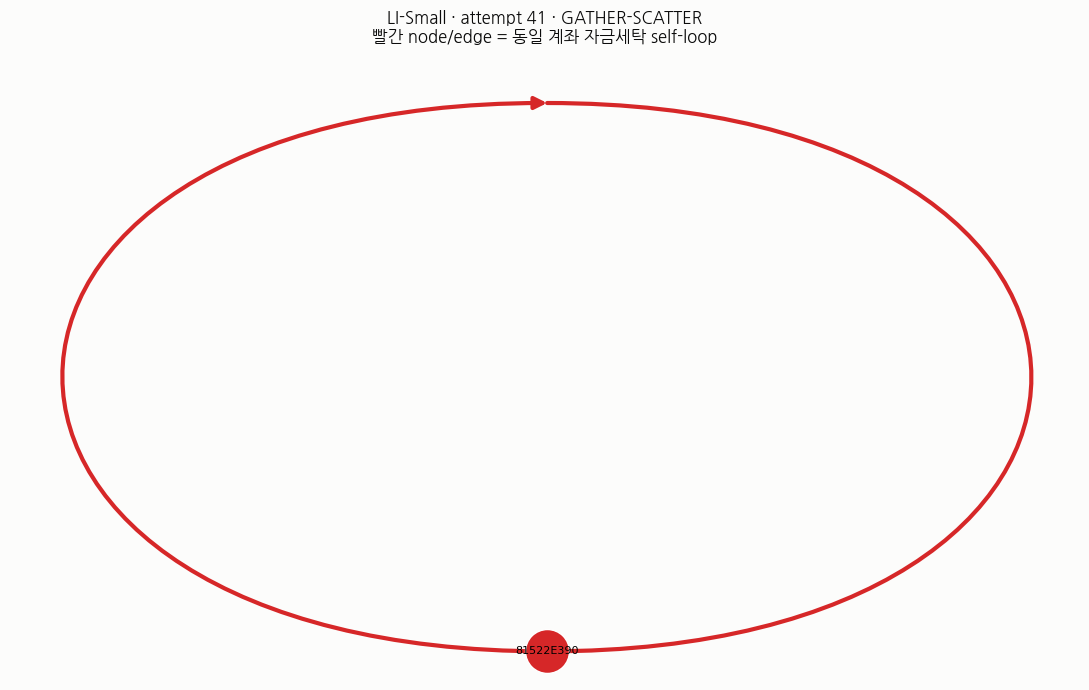

,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,dataset_id,attempt_id,pattern_type,pattern_desc,attempt_edge_index,pattern_row_index,from_bank_canon,to_bank_canon,src,dst,is_self_loop,key_occurrence
3570,2022-09-03 08:56:00,0115,81522E390,0115,81522E390,40877.23,Shekel,40877.23,Shekel,ACH,1,LI-Small,41,GATHER-SCATTER,Max 1-degree Fan-In,0,361,115,115,LI-Small|115|81522E390,LI-Small|115|81522E390,True,0


In [77]:
isolated_cases = sa_diagnostics[
    sa_diagnostics[
        "account_role_without_self_loop"
    ]
    == "ISOLATED_SELF_LOOP"
]

display(isolated_cases)

isolated_case_id = int(
    isolated_cases.iloc[0]["case_id"]
)

sa_show_case(isolated_case_id)
sa_plot_attempt(isolated_case_id)

In [79]:
# ============================================================
# sa_plot_attempt 실행에 필요한 Patterns 데이터 준비
# 선행 조건: catalog가 생성되어 있어야 함
# ============================================================

import csv
from pathlib import Path

import pandas as pd


SA_PATTERN_COLUMNS = [
    "Timestamp",
    "From Bank",
    "From Account",
    "To Bank",
    "To Account",
    "Amount Received",
    "Receiving Currency",
    "Amount Paid",
    "Payment Currency",
    "Payment Format",
    "Is Laundering",
]


def sa_canon_bank(value):
    """
    Bank ID의 선행 0을 제거해 비교용 ID로 변환한다.
    원본 값은 수정하지 않는다.

    예:
        0048309 -> 48309
        0118    -> 118
    """
    text = str(value).strip()

    if text.endswith(".0"):
        text = text[:-2]

    result = text.lstrip("0")
    return result if result else "0"


def sa_account_node(dataset_id, bank_id, account_id):
    """
    데이터셋·은행·계좌를 결합한 고유 그래프 노드 ID
    """
    return (
        f"{dataset_id}|"
        f"{sa_canon_bank(bank_id)}|"
        f"{str(account_id).strip()}"
    )


def sa_get_catalog_path(dataset_id, file_type):
    """
    catalog에서 Small 데이터 파일 경로를 찾는다.

    dataset_id 예:
        HI-Small
        LI-Small

    file_type 예:
        Trans
        Patterns
        accounts
    """
    ratio, size = dataset_id.split("-", 1)

    selected = catalog[
        catalog["ratio"].astype(str).eq(ratio)
        & catalog["size"].astype(str).eq(size)
        & catalog["type"].astype(str).eq(file_type)
    ]

    if selected.empty:
        raise FileNotFoundError(
            f"catalog에서 {dataset_id}_{file_type} 파일을 찾지 못했습니다."
        )

    return Path(selected.iloc[0]["path"])


def sa_parse_patterns(dataset_id):
    """
    Patterns.txt의 BEGIN~END 블록을 파싱한다.

    attempt_id는 각 데이터셋 안에서 1부터 시작한다.
    """
    pattern_path = sa_get_catalog_path(
        dataset_id=dataset_id,
        file_type="Patterns",
    )

    records = []

    attempt_id = 0
    pattern_type = None
    pattern_description = None
    attempt_edge_index = 0
    pattern_row_index = 0

    with open(pattern_path, mode="r", encoding="utf-8") as file:
        for raw_line in file:
            line = raw_line.strip()

            if not line:
                continue

            # 새로운 자금세탁 attempt 시작
            if line.startswith("BEGIN LAUNDERING ATTEMPT"):
                attempt_id += 1
                attempt_edge_index = 0

                header = line.replace(
                    "BEGIN LAUNDERING ATTEMPT - ",
                    "",
                    1,
                )

                pattern_type, separator, pattern_description = (
                    header.partition(":")
                )

                pattern_type = pattern_type.strip()
                pattern_description = pattern_description.strip()

                continue

            if line.startswith("END LAUNDERING ATTEMPT"):
                continue

            values = next(csv.reader([line]))

            if len(values) != len(SA_PATTERN_COLUMNS):
                raise ValueError(
                    f"{pattern_path.name}: Patterns 거래 행의 "
                    f"컬럼 수가 {len(values)}개입니다.\n"
                    f"예상 컬럼 수: {len(SA_PATTERN_COLUMNS)}\n"
                    f"행 내용: {line[:200]}"
                )

            record = dict(zip(SA_PATTERN_COLUMNS, values))

            record.update({
                "dataset_id": dataset_id,
                "attempt_id": attempt_id,
                "pattern_type": pattern_type,
                "pattern_desc": pattern_description,
                "attempt_edge_index": attempt_edge_index,
                "pattern_row_index": pattern_row_index,
            })

            records.append(record)

            attempt_edge_index += 1
            pattern_row_index += 1

    patterns = pd.DataFrame(records)

    # 자료형 변환
    patterns["Timestamp"] = pd.to_datetime(
        patterns["Timestamp"],
        format="%Y/%m/%d %H:%M",
        errors="raise",
    )

    patterns["Amount Received"] = pd.to_numeric(
        patterns["Amount Received"],
        errors="raise",
    )

    patterns["Amount Paid"] = pd.to_numeric(
        patterns["Amount Paid"],
        errors="raise",
    )

    patterns["Is Laundering"] = pd.to_numeric(
        patterns["Is Laundering"],
        errors="raise",
    ).astype("int8")

    # 비교용 Bank ID
    patterns["from_bank_canon"] = (
        patterns["From Bank"].map(sa_canon_bank)
    )

    patterns["to_bank_canon"] = (
        patterns["To Bank"].map(sa_canon_bank)
    )

    # 그래프 노드 ID
    patterns["src"] = [
        sa_account_node(dataset_id, bank, account)
        for bank, account in zip(
            patterns["From Bank"],
            patterns["From Account"],
        )
    ]

    patterns["dst"] = [
        sa_account_node(dataset_id, bank, account)
        for bank, account in zip(
            patterns["To Bank"],
            patterns["To Account"],
        )
    ]

    patterns["is_self_loop"] = patterns["src"].eq(patterns["dst"])

    return patterns

In [81]:
# ============================================================
# HI-Small과 LI-Small Patterns 파싱
# 데이터셋을 학습용으로 합치는 것이 아니라,
# 시각화 대상 목록을 하나의 테이블로 정리하는 것임
# ============================================================

sa_patterns_all = pd.concat(
    [
        sa_parse_patterns("HI-Small"),
        sa_parse_patterns("LI-Small"),
    ],
    ignore_index=True,
)

# 자금세탁 라벨이면서 송신·수신 복합 계좌가 같은 거래
sa_self_detail = (
    sa_patterns_all[
        sa_patterns_all["Is Laundering"].eq(1)
        & sa_patterns_all["is_self_loop"]
    ]
    .sort_values(
        ["dataset_id", "pattern_row_index"],
        kind="stable",
    )
    .reset_index(drop=True)
)

print("전체 Patterns 거래:", f"{len(sa_patterns_all):,}건")
print("동일 계좌 자금세탁 거래:", f"{len(sa_self_detail):,}건")

display(
    sa_self_detail[
        [
            "dataset_id",
            "attempt_id",
            "Timestamp",
            "From Bank",
            "From Account",
            "Amount Paid",
            "Payment Currency",
            "Payment Format",
            "pattern_type",
            "attempt_edge_index",
        ]
    ].rename_axis("case_no")
)

전체 Patterns 거래: 4,232건
동일 계좌 자금세탁 거래: 14건


,dataset_id,attempt_id,Timestamp,From Bank,From Account,Amount Paid,Payment Currency,Payment Format,pattern_type,attempt_edge_index
case_no,,,,,,,,,,
0,HI-Small,3,2022-09-04 05:03:00,0048309,811C599A0,48649.42,Saudi Riyal,ACH,GATHER-SCATTER,3
1,HI-Small,35,2022-09-01 14:04:00,015231,80266F880,14998.24,Euro,ACH,GATHER-SCATTER,1
2,HI-Small,98,2022-09-03 19:55:00,015231,80266F880,4895.52,Euro,ACH,GATHER-SCATTER,1
3,HI-Small,100,2022-09-04 21:37:00,0150240,812D22980,71726.48,Saudi Riyal,ACH,GATHER-SCATTER,3
4,HI-Small,171,2022-09-05 15:41:00,023691,8021353D0,13178.60,Euro,ACH,GATHER-SCATTER,1
5,HI-Small,183,2022-09-09 09:08:00,0048309,811C599A0,47970.16,Saudi Riyal,ACH,GATHER-SCATTER,3
6,HI-Small,202,2022-09-06 23:04:00,0119,812A09CF0,30855.39,Saudi Riyal,ACH,GATHER-SCATTER,1
7,HI-Small,222,2022-09-10 23:17:00,0119,811C597B0,14144807.18,Saudi Riyal,ACH,GATHER-SCATTER,3
8,HI-Small,259,2022-09-11 05:36:00,0048309,811C599A0,52436.24,Saudi Riyal,ACH,GATHER-SCATTER,3


In [82]:
# ============================================================
# self-loop 자금세탁 attempt + 해당 계좌의 정상 거래 함께 시각화
#
# 선행 조건
# - catalog
# - self_detail 또는 sa_self_detail
# - patterns_all 또는 sa_patterns_all
# 가 앞 셀에서 만들어져 있어야 합니다.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# 기존 코드의 변수명 차이를 자동으로 처리
if "sa_self_detail" in globals():
    _sa_cases = sa_self_detail.copy()
elif "self_detail" in globals():
    _sa_cases = self_detail.copy()
else:
    raise NameError(
        "sa_self_detail 또는 self_detail이 없습니다. "
        "동일 계좌 자금세탁 분석 셀을 먼저 실행하세요."
    )

if "sa_patterns_all" in globals():
    _sa_patterns = sa_patterns_all.copy()
elif "patterns_all" in globals():
    _sa_patterns = patterns_all.copy()
else:
    raise NameError(
        "sa_patterns_all 또는 patterns_all이 없습니다. "
        "Patterns 파싱 셀을 먼저 실행하세요."
    )


def _sa_canon_bank_expr(column_name):
    """Polars용 Bank ID 정규화: 0048309 -> 48309"""
    value = (
        pl.col(column_name)
        .cast(pl.Utf8)
        .str.strip_chars()
        .str.replace(r"\.0$", "")
        .str.strip_chars_start("0")
    )
    return pl.when(value == "").then(pl.lit("0")).otherwise(value)


def _sa_find_trans_path(dataset_id):
    """
    catalog에서 HI-Small_Trans.csv 또는 LI-Small_Trans.csv를 찾는다.
    """
    ratio, size = dataset_id.split("-", 1)

    matched = catalog[
        catalog["ratio"].astype(str).eq(ratio)
        & catalog["size"].astype(str).eq(size)
        & catalog["type"].astype(str).eq("Trans")
    ]

    if matched.empty:
        raise FileNotFoundError(
            f"catalog에서 {dataset_id}_Trans.csv를 찾지 못했습니다."
        )

    return Path(matched.iloc[0]["path"])


def _sa_load_normal_history(dataset_id, focus_node):
    """
    self-loop 계좌가 송신 또는 수신 계좌로 참여한 정상 거래 전체를 읽는다.

    focus_node 형식:
        dataset_id|canonical_bank_id|account_id
    """
    _, focus_bank, focus_account = focus_node.split("|", 2)
    trans_path = _sa_find_trans_path(dataset_id)

    lf = (
        pl.scan_csv(
            trans_path,
            schema_overrides={
                "Timestamp": pl.Utf8,
                "From Bank": pl.Utf8,
                "Account": pl.Utf8,
                "To Bank": pl.Utf8,
                "Account_duplicated_0": pl.Utf8,
                "Amount Received": pl.Float64,
                "Receiving Currency": pl.Utf8,
                "Amount Paid": pl.Float64,
                "Payment Currency": pl.Utf8,
                "Payment Format": pl.Utf8,
                "Is Laundering": pl.Int8,
            },
            infer_schema_length=10_000,
        )
        .with_columns(
            _sa_canon_bank_expr("From Bank").alias("from_bank_canon"),
            _sa_canon_bank_expr("To Bank").alias("to_bank_canon"),
            pl.col("Timestamp")
            .str.strptime(
                pl.Datetime,
                format="%Y/%m/%d %H:%M",
                strict=False,
            )
            .alias("Timestamp_dt"),
        )
        .filter(
            (pl.col("Is Laundering") == 0)
            & (
                (
                    (pl.col("from_bank_canon") == focus_bank)
                    & (pl.col("Account") == focus_account)
                )
                |
                (
                    (pl.col("to_bank_canon") == focus_bank)
                    & (pl.col("Account_duplicated_0") == focus_account)
                )
            )
        )
        .select(
            "Timestamp_dt",
            "From Bank",
            "Account",
            "To Bank",
            "Account_duplicated_0",
            "Amount Paid",
            "Payment Currency",
            "Payment Format",
            "Is Laundering",
            "from_bank_canon",
            "to_bank_canon",
        )
    )

    # pyarrow가 없어도 실행되도록 dict를 경유
    normal = pd.DataFrame(lf.collect(engine="streaming").to_dicts())

    if normal.empty:
        return normal

    normal = normal.rename(
        columns={
            "Timestamp_dt": "Timestamp",
            "Account": "From Account",
            "Account_duplicated_0": "To Account",
        }
    )

    normal["Timestamp"] = pd.to_datetime(normal["Timestamp"])

    normal["src"] = (
        dataset_id
        + "|"
        + normal["from_bank_canon"].astype(str)
        + "|"
        + normal["From Account"].astype(str)
    )

    normal["dst"] = (
        dataset_id
        + "|"
        + normal["to_bank_canon"].astype(str)
        + "|"
        + normal["To Account"].astype(str)
    )

    normal["is_self_loop"] = normal["src"].eq(normal["dst"])

    return normal.sort_values("Timestamp").reset_index(drop=True)


def _sa_short_label(node):
    """
    그래프 노드 라벨: Bank ID | Account ID
    """
    _, bank_id, account_id = node.split("|", 2)
    return f"{bank_id} | {account_id}"


def sa_plot_attempt(
    case_no,
    normal_window="7D",
    max_normal_edges=100,
    seed=42,
    figsize=(15, 10),
):
    """
    self-loop 자금세탁 attempt와 해당 계좌의 정상 거래를 함께 그린다.

    Parameters
    ----------
    case_no : int
        0부터 시작하는 self-loop 케이스 번호.
        예: sa_plot_attempt(0)

    normal_window : str 또는 None
        self-loop 발생 시점을 기준으로 정상 거래를 표시할 기간.
        "24H", "3D", "7D"처럼 지정한다.
        None이면 해당 계좌의 전체 정상 거래 기간을 사용한다.

    max_normal_edges : int 또는 None
        정상 거래가 너무 많을 때 표시할 최대 개수.
        self-loop 시각과 가까운 정상 거래부터 선택한다.
        None이면 전부 표시한다.

    seed : int
        그래프 배치 재현용 난수값.

    figsize : tuple
        그래프 크기.
    """
    if not isinstance(case_no, (int, np.integer)):
        raise TypeError("case_no는 0부터 시작하는 정수여야 합니다.")

    if case_no < 0 or case_no >= len(_sa_cases):
        raise IndexError(
            f"case_no는 0부터 {len(_sa_cases) - 1}까지 가능합니다."
        )

    # --------------------------------------------------------
    # 1. 선택한 self-loop와 자금세탁 attempt
    # --------------------------------------------------------
    focus_tx = _sa_cases.iloc[case_no]

    dataset_id = focus_tx["dataset_id"]
    attempt_id = int(focus_tx["attempt_id"])
    focus_node = focus_tx["src"]
    focus_time = pd.Timestamp(focus_tx["Timestamp"])

    attempt = _sa_patterns[
        (_sa_patterns["dataset_id"] == dataset_id)
        & (_sa_patterns["attempt_id"].astype(int) == attempt_id)
    ].copy()

    attempt["Timestamp"] = pd.to_datetime(attempt["Timestamp"])
    attempt = attempt.sort_values("attempt_edge_index").reset_index(drop=True)

    # --------------------------------------------------------
    # 2. 해당 계좌의 정상 거래 전체 조회
    # --------------------------------------------------------
    normal_all = _sa_load_normal_history(
        dataset_id=dataset_id,
        focus_node=focus_node,
    )

    normal_total_count = len(normal_all)
    normal_total_nonself = (
        int((~normal_all["is_self_loop"]).sum())
        if not normal_all.empty else 0
    )
    normal_total_self = (
        int(normal_all["is_self_loop"].sum())
        if not normal_all.empty else 0
    )

    # --------------------------------------------------------
    # 3. 사건 전후 기간 필터
    # --------------------------------------------------------
    normal_view = normal_all.copy()

    if normal_window is not None and not normal_view.empty:
        delta = pd.Timedelta(normal_window)

        normal_view = normal_view[
            normal_view["Timestamp"].between(
                focus_time - delta,
                focus_time + delta,
                inclusive="both",
            )
        ].copy()

    normal_window_count = len(normal_view)

    # 정상 거래가 너무 많으면 사건 시각과 가까운 순서로 제한
    if (
        max_normal_edges is not None
        and len(normal_view) > max_normal_edges
    ):
        normal_view["time_distance"] = (
            normal_view["Timestamp"] - focus_time
        ).abs()

        normal_view = (
            normal_view
            .sort_values(["time_distance", "Timestamp"])
            .head(max_normal_edges)
            .drop(columns="time_distance")
            .sort_values("Timestamp")
            .reset_index(drop=True)
        )

    # --------------------------------------------------------
    # 4. MultiDiGraph 생성
    # --------------------------------------------------------
    graph = nx.MultiDiGraph()

    # 회색: 정상 거래
    for _, edge in normal_view.iterrows():
        graph.add_edge(
            edge["src"],
            edge["dst"],
            edge_class="normal",
            is_self_loop=bool(edge["is_self_loop"]),
            timestamp=edge["Timestamp"],
            amount=edge["Amount Paid"],
            currency=edge["Payment Currency"],
        )

    # 파란색: 해당 자금세탁 attempt 거래
    # 분석 대상 self-loop만 빨간색으로 별도 표시
    for _, edge in attempt.iterrows():
        is_focus_self_loop = (
            edge["src"] == focus_node
            and edge["dst"] == focus_node
            and int(edge["attempt_edge_index"])
                == int(focus_tx["attempt_edge_index"])
        )

        graph.add_edge(
            edge["src"],
            edge["dst"],
            edge_class=(
                "focus_self_loop"
                if is_focus_self_loop
                else "laundering_attempt"
            ),
            is_self_loop=bool(edge["src"] == edge["dst"]),
            timestamp=edge["Timestamp"],
            amount=edge["Amount Paid"],
            currency=edge["Payment Currency"],
        )

    # --------------------------------------------------------
    # 5. 노드 유형
    # --------------------------------------------------------
    attempt_nodes = set(attempt["src"]) | set(attempt["dst"])

    node_colors = []
    node_sizes = []

    for node in graph.nodes:
        if node == focus_node:
            node_colors.append("#dc2626")       # 빨강
            node_sizes.append(1_250)
        elif node in attempt_nodes:
            node_colors.append("#72a9e0")       # 파랑
            node_sizes.append(650)
        else:
            node_colors.append("#d9e0e8")       # 연한 회색
            node_sizes.append(360)

    # self-loop를 제외한 단순 그래프로 위치 계산
    layout_graph = nx.Graph()

    for u, v in graph.edges():
        if u != v:
            layout_graph.add_edge(u, v)

    layout_graph.add_nodes_from(graph.nodes)

    pos = nx.spring_layout(
        layout_graph,
        seed=seed,
        k=1.5 / np.sqrt(max(len(layout_graph), 1)),
        iterations=150,
    )

    # --------------------------------------------------------
    # 6. 엣지 유형 분리
    # --------------------------------------------------------
    normal_nonself_edges = []
    normal_self_edges = []
    laundering_edges = []
    focus_self_edges = []

    for u, v, key, data in graph.edges(keys=True, data=True):
        edge_tuple = (u, v, key)

        if data["edge_class"] == "normal":
            if u == v:
                normal_self_edges.append(edge_tuple)
            else:
                normal_nonself_edges.append(edge_tuple)

        elif data["edge_class"] == "focus_self_loop":
            focus_self_edges.append(edge_tuple)

        else:
            laundering_edges.append(edge_tuple)

    # --------------------------------------------------------
    # 7. 시각화
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="white",
        linewidths=1.2,
        ax=ax,
    )

    # 정상 거래: 회색
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=normal_nonself_edges,
        edge_color="#aeb8c4",
        width=0.9,
        alpha=0.32,
        arrows=True,
        arrowsize=10,
        connectionstyle="arc3,rad=0.06",
        ax=ax,
    )

    # 정상 self-loop: 회색 점선
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=normal_self_edges,
        edge_color="#7d8792",
        width=1.4,
        alpha=0.55,
        style="dashed",
        arrows=True,
        arrowsize=12,
        connectionstyle="arc3,rad=0.28",
        ax=ax,
    )

    # 해당 attempt의 자금세탁 거래: 파랑
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=laundering_edges,
        edge_color="#3978ba",
        width=2.0,
        alpha=0.85,
        arrows=True,
        arrowsize=17,
        connectionstyle="arc3,rad=0.09",
        ax=ax,
    )

    # 분석 대상 자금세탁 self-loop: 빨강
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=focus_self_edges,
        edge_color="#dc2626",
        width=4.0,
        alpha=1.0,
        arrows=True,
        arrowsize=20,
        connectionstyle="arc3,rad=0.38",
        ax=ax,
    )

    nx.draw_networkx_labels(
        graph,
        pos,
        labels={node: _sa_short_label(node) for node in graph.nodes},
        font_size=7,
        ax=ax,
    )

    window_label = (
        "전체 기간"
        if normal_window is None
        else f"사건 시점 ± {normal_window}"
    )

    ax.set_title(
        f"case {case_no} · {dataset_id} · "
        f"attempt {attempt_id} · {focus_tx['pattern_type']}\n"
        f"빨강=self-loop · 파랑=자금세탁 attempt · "
        f"회색=같은 계좌의 정상 거래 ({window_label})",
        fontsize=14,
    )

    legend_items = [
        Patch(
            facecolor="#dc2626",
            edgecolor="white",
            label="self-loop 발생 계좌",
        ),
        Patch(
            facecolor="#72a9e0",
            edgecolor="white",
            label="자금세탁 attempt 계좌",
        ),
        Patch(
            facecolor="#d9e0e8",
            edgecolor="white",
            label="정상 거래에서만 등장한 계좌",
        ),
        Line2D(
            [0], [0],
            color="#dc2626",
            linewidth=4,
            label="분석 대상 자금세탁 self-loop",
        ),
        Line2D(
            [0], [0],
            color="#3978ba",
            linewidth=2,
            label="자금세탁 attempt 거래",
        ),
        Line2D(
            [0], [0],
            color="#aeb8c4",
            linewidth=1,
            alpha=0.6,
            label="정상 거래",
        ),
    ]

    ax.legend(
        handles=legend_items,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        frameon=True,
    )

    ax.text(
        0.01,
        0.01,
        (
            f"정상 거래 전체: {normal_total_count:,}건 "
            f"(타계좌 {normal_total_nonself:,}, "
            f"self-loop {normal_total_self:,})\n"
            f"선택 기간 내 정상 거래: {normal_window_count:,}건 · "
            f"실제 표시: {len(normal_view):,}건\n"
            f"자금세탁 attempt 거래: {len(attempt):,}건"
        ),
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="bottom",
        bbox={
            "boxstyle": "round,pad=0.5",
            "facecolor": "white",
            "edgecolor": "#cbd5e1",
            "alpha": 0.92,
        },
    )

    ax.axis("off")
    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame([{
        "case_no": case_no,
        "dataset_id": dataset_id,
        "attempt_id": attempt_id,
        "focus_account": focus_node,
        "self_loop_timestamp": focus_time,
        "attempt_edges": len(attempt),
        "normal_transactions_all_period": normal_total_count,
        "normal_nonself_all_period": normal_total_nonself,
        "normal_self_loops_all_period": normal_total_self,
        "normal_transactions_in_window": normal_window_count,
        "normal_transactions_displayed": len(normal_view),
    }])

    display(summary)

    return {
        "focus_transaction": focus_tx,
        "attempt_transactions": attempt,
        "normal_transactions_all": normal_all,
        "normal_transactions_displayed": normal_view,
        "summary": summary,
        "graph": graph,
    }

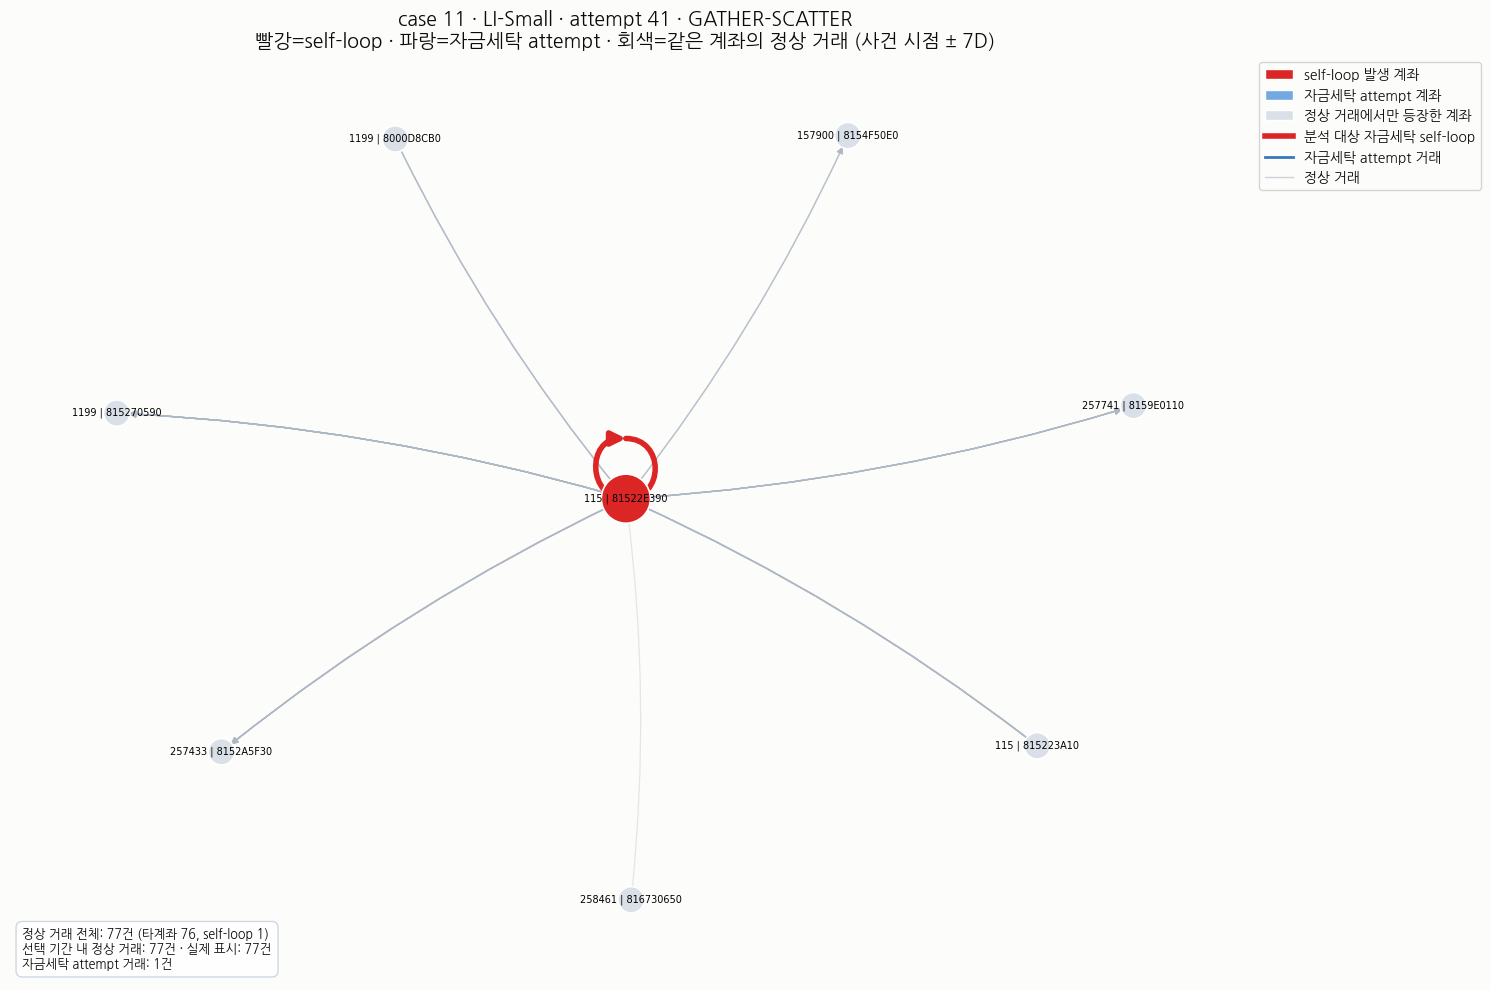

,case_no,dataset_id,attempt_id,focus_account,self_loop_timestamp,attempt_edges,normal_transactions_all_period,normal_nonself_all_period,normal_self_loops_all_period,normal_transactions_in_window,normal_transactions_displayed
0,11,LI-Small,41,LI-Small|115|81522E390,2022-09-03 08:56:00,1,77,76,1,77,77


{'focus_transaction': Timestamp                2022-09-03 08:56:00
 From Bank                               0115
 From Account                       81522E390
 To Bank                                 0115
 To Account                         81522E390
 Amount Received                     40877.23
 Receiving Currency                    Shekel
 Amount Paid                         40877.23
 Payment Currency                      Shekel
 Payment Format                           ACH
 Is Laundering                              1
 dataset_id                          LI-Small
 attempt_id                                41
 pattern_type                  GATHER-SCATTER
 pattern_desc             Max 1-degree Fan-In
 attempt_edge_index                         0
 pattern_row_index                        361
 from_bank_canon                          115
 to_bank_canon                            115
 src                   LI-Small|115|81522E390
 dst                   LI-Small|115|81522E390
 is_self_loop

In [84]:
sa_plot_attempt(11)